# 04. PyTorch 본학습 - SSD JPG / GPU 강제사용 / 수업 수준 안정화 버전9

이번 버전은 복잡한 helper module / spawn 멀티프로세싱을 사용하지 않고
수업에서 이해하고 설명하기 쉬운 기본 PyTorch 구조로 안정화했다.

설정:
- 전체 Training 223,578장
- 전체 Validation 52,126장
- C: SSD 복사본 사용
- cuda:0 강제 사용
- Batch Size 128
- num_workers 0
- pin_memory True
- AMP / channels_last / TF32 / cuDNN benchmark 유지
- 50 batch마다 학습 진행상황 출력
- 100 batch마다 Validation 진행상황 출력

결과 태그:
`GPU강제사용_수업수준안정화버전9_B128`

## 1. 학습 환경 및 데이터 연결

- 1-1. 라이브러리 / GPU 확인
- 1-2. 프로젝트 경로 / 클래스 설정
- 1-3. 기존 컬러 JPG/JPEG 존재 여부 및 개수 확인
- 1-4. 컬러 JPG/JPEG와 JSON 라벨 연결
- 1-5. 학습 직전 데이터 수 검증

컬러 JPG/JPEG 변환은 이미 완료되었으므로 다시 변환하지 않는다.
`02_data/processed/processed/train`, `valid`의 기존 PNG 파일을 직접 사용한다.

### 1-1. 라이브러리 / 랜덤 시드 / GPU 가속 설정

필요한 라이브러리를 불러오고 Random Seed를 42로 설정한다.

이번 속도 우선 버전에서는 RTX 4060의 연산 성능을 더 활용하기 위해 다음을 추가한다.

- `torch.backends.cudnn.benchmark = True`
- TF32 허용
- `torch.set_float32_matmul_precision("high")`
- AMP 사용 준비

또한 PNG 로딩은 PIL 대신 `torchvision.io.read_image()`를 사용한다.

In [1]:
# ==================================================
# 1-1. 필수 라이브러리 전체 Import
# ==================================================

# Python 기본
import json
import time
import shutil
import subprocess
from pathlib import Path

# 데이터 처리
import numpy as np
import pandas as pd

# 시각화
import matplotlib.pyplot as plt

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# torchvision
from torchvision import models
from torchvision.io import read_image, ImageReadMode
from torchvision.transforms.functional import convert_image_dtype, normalize

# scikit-learn 평가 지표
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

print("필수 라이브러리 import 완료")

# --------------------------------------------------
# PyTorch CUDA GPU 강제 사용 설정
# --------------------------------------------------

# CUDA가 없으면 CPU로 자동 전환하지 않고 즉시 중단
if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA GPU를 사용할 수 없습니다. "
        "PyTorch CUDA 설치 / NVIDIA 드라이버 / 가상환경을 확인하세요."
    )

# RTX 4060이 연결된 0번 GPU를 명시적으로 사용
torch.cuda.set_device(0)
device = torch.device("cuda:0")

print("PyTorch 버전:", torch.__version__)
print("PyTorch CUDA 빌드:", torch.version.cuda)
print("CUDA 사용 가능:", torch.cuda.is_available())
print("현재 GPU index:", torch.cuda.current_device())
print("현재 GPU:", torch.cuda.get_device_name(0))
print("학습 device:", device)

# GPU 가속 설정
torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

try:
    torch.set_float32_matmul_precision("high")
except Exception:
    pass

torch.cuda.empty_cache()
print("초기 GPU 메모리 할당:",
      f"{torch.cuda.memory_allocated(0) / 1024**3:.3f} GB")

필수 라이브러리 import 완료
PyTorch 버전: 2.5.1+cu121
PyTorch CUDA 빌드: 12.1
CUDA 사용 가능: True
현재 GPU index: 0
현재 GPU: NVIDIA GeForce RTX 4060
학습 device: cuda:0
초기 GPU 메모리 할당: 0.000 GB


### 1-2. HDD 원본 경로 / SSD 복사 경로 / 프로젝트 경로 설정

이번 버전은 D: HDD의 기존 JPG/JPEG를 C: SSD로 **복사한 뒤**,
학습에서는 SSD 복사본만 읽는다.

중요:
- D: 원본은 그대로 유지한다.
- `move`, `rename`, `delete`를 사용하지 않는다.
- 복사는 Windows `robocopy`를 사용한다.
- 복사가 이미 완료되어 있다면 파일 개수를 확인하고 재복사를 최소화한다.

In [2]:
# --------------------------------------------------
# 프로젝트 기본 경로
# --------------------------------------------------
PROJECT_ROOT = Path(r"D:\emotion_recognition_project")

# D: HDD 원본 - 절대 삭제/이동하지 않음
HDD_TRAIN_DIR = PROJECT_ROOT / "02_data" / "processed" / "train"
HDD_VALID_DIR = PROJECT_ROOT / "02_data" / "processed" / "valid"

# C: SSD 복사본 - 실제 학습은 이 경로 사용
SSD_ROOT = Path(r"C:\emotion_fast_data")
SSD_TRAIN_DIR = SSD_ROOT / "train"
SSD_VALID_DIR = SSD_ROOT / "valid"

# 이후 학습 코드가 사용할 경로
COLOR_TRAIN_DIR = SSD_TRAIN_DIR
COLOR_VALID_DIR = SSD_VALID_DIR

# JSON 라벨은 기존 D: 프로젝트 경로 그대로 사용
TRAIN_LABEL_DIR = PROJECT_ROOT / "02_data" / "labels" / "train"
VALID_LABEL_DIR = PROJECT_ROOT / "02_data" / "labels" / "valid"

# 모델 / 결과 저장 경로도 기존 프로젝트 폴더 그대로
MODEL_DIR = PROJECT_ROOT / "05_models"
OUTPUT_DIR = PROJECT_ROOT / "06_outputs"

EXPERIMENT_TAG = "GPU강제사용_수업수준안정화버전9_B128"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
SSD_ROOT.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = ["기쁨", "당황", "분노", "불안", "상처", "슬픔", "중립"]
LABEL_TO_IDX = {label: idx for idx, label in enumerate(CLASS_NAMES)}

print("D: HDD 원본 Training:", HDD_TRAIN_DIR)
print("D: HDD 원본 Validation:", HDD_VALID_DIR)
print("C: SSD 복사 Training:", SSD_TRAIN_DIR)
print("C: SSD 복사 Validation:", SSD_VALID_DIR)
print("실제 학습 Training:", COLOR_TRAIN_DIR)
print("실제 학습 Validation:", COLOR_VALID_DIR)
print("실험 태그:", EXPERIMENT_TAG)

D: HDD 원본 Training: D:\emotion_recognition_project\02_data\processed\train
D: HDD 원본 Validation: D:\emotion_recognition_project\02_data\processed\valid
C: SSD 복사 Training: C:\emotion_fast_data\train
C: SSD 복사 Validation: C:\emotion_fast_data\valid
실제 학습 Training: C:\emotion_fast_data\train
실제 학습 Validation: C:\emotion_fast_data\valid
실험 태그: GPU강제사용_수업수준안정화버전9_B128


### 1-3. D: HDD → C: SSD 복사

여기서는 **이동이 아니라 복사**만 한다.

Windows의 `robocopy`를 이용해 D:의 `train`, `valid` 폴더를 C:로 복사한다.

`/E`
- 하위 폴더 포함

`/MT:16`
- 16개 스레드로 병렬 복사

`/R:2 /W:1`
- 실패 시 재시도 횟수와 대기 시간을 줄여 전체 복사 지연을 방지

중요:
- `robocopy`는 원본 파일을 삭제하지 않는다.
- `/MOVE`, `/MOV`, `/MIR` 옵션은 사용하지 않는다.
- 이미 복사된 동일 파일은 대부분 건너뛴다.

In [3]:
def count_jpg_jpeg(root_dir):
    if not root_dir.exists():
        return 0

    return sum(
        1
        for path in root_dir.rglob("*")
        if path.is_file() and path.suffix.lower() in {".jpg", ".jpeg"}
    )


def robocopy_copy(source_dir, target_dir):
    """
    D: 원본을 C: SSD로 '복사'한다.
    원본은 삭제하거나 이동하지 않는다.
    """
    source_dir = Path(source_dir)
    target_dir = Path(target_dir)

    if not source_dir.exists():
        raise FileNotFoundError(f"원본 폴더가 없습니다: {source_dir}")

    target_dir.mkdir(parents=True, exist_ok=True)

    command = [
        "robocopy",
        str(source_dir),
        str(target_dir),
        "*.jpg",
        "*.jpeg",
        "/E",
        "/MT:16",
        "/R:2",
        "/W:1",
        "/NFL",
        "/NDL",
        "/NJH",
        "/NJS",
        "/NP",
    ]

    print(f"\n[복사 시작]")
    print(f"원본: {source_dir}")
    print(f"대상: {target_dir}")

    result = subprocess.run(command)

    # robocopy는 0~7을 정상/경고 수준의 성공 코드로 사용한다.
    if result.returncode >= 8:
        raise RuntimeError(
            f"robocopy 복사 실패. 반환 코드: {result.returncode}"
        )

    print(f"[복사 명령 완료] robocopy code = {result.returncode}")


EXPECTED_TRAIN = 223578
EXPECTED_VALID = 52126

# C: SSD 여유 공간 확인
total, used, free = shutil.disk_usage(r"C:\\")
print(f"C: 남은 용량: {free / (1024**3):.1f} GB")

# 현재 복사본 개수 확인
ssd_train_before = count_jpg_jpeg(SSD_TRAIN_DIR)
ssd_valid_before = count_jpg_jpeg(SSD_VALID_DIR)

print("복사 전 SSD Training JPG/JPEG:", ssd_train_before)
print("복사 전 SSD Validation JPG/JPEG:", ssd_valid_before)

# 필요한 경우에만 복사
if ssd_train_before != EXPECTED_TRAIN:
    robocopy_copy(HDD_TRAIN_DIR, SSD_TRAIN_DIR)
else:
    print("Training 복사본이 이미 완성되어 있어 복사를 건너뜁니다.")

if ssd_valid_before != EXPECTED_VALID:
    robocopy_copy(HDD_VALID_DIR, SSD_VALID_DIR)
else:
    print("Validation 복사본이 이미 완성되어 있어 복사를 건너뜁니다.")

# 복사 후 검증
ssd_train_after = count_jpg_jpeg(SSD_TRAIN_DIR)
ssd_valid_after = count_jpg_jpeg(SSD_VALID_DIR)

print("\n[복사 후 검증]")
print("SSD Training JPG/JPEG:", ssd_train_after)
print("SSD Validation JPG/JPEG:", ssd_valid_after)

assert ssd_train_after == EXPECTED_TRAIN, (
    f"SSD Training 복사 수가 예상과 다릅니다: {ssd_train_after}"
)
assert ssd_valid_after == EXPECTED_VALID, (
    f"SSD Validation 복사 수가 예상과 다릅니다: {ssd_valid_after}"
)

print("\nSSD 복사 완료")
print("※ D: 원본은 그대로 유지되어 있습니다.")

C: 남은 용량: 303.2 GB
복사 전 SSD Training JPG/JPEG: 223578
복사 전 SSD Validation JPG/JPEG: 52126
Training 복사본이 이미 완성되어 있어 복사를 건너뜁니다.
Validation 복사본이 이미 완성되어 있어 복사를 건너뜁니다.

[복사 후 검증]
SSD Training JPG/JPEG: 223578
SSD Validation JPG/JPEG: 52126

SSD 복사 완료
※ D: 원본은 그대로 유지되어 있습니다.


### 1-4. SSD JPG/JPEG와 JSON 라벨 연결

이 단계부터 실제 학습 이미지는:

- `C:\emotion_fast_data\train`
- `C:\emotion_fast_data\valid`

의 SSD 복사본을 사용한다.

JSON 라벨은 기존 D: 프로젝트 경로를 그대로 사용한다.

In [4]:
def build_dataframe(image_dir, label_dir):
    # JPG/JPEG만 대상으로 stem -> 실제 파일 경로 매핑
    image_map = {
        path.stem: path
        for path in image_dir.rglob("*")
        if path.is_file() and path.suffix.lower() in {".jpg", ".jpeg"}
    }

    records = []

    for json_path in sorted(label_dir.rglob("*.json")):
        with open(json_path, "r", encoding="utf-8") as f:
            label_data = json.load(f)

        for record in label_data:
            original_name = record["filename"]
            stem = Path(original_name).stem
            label = record["faceExp_uploader"]

            if stem in image_map and label in LABEL_TO_IDX:
                records.append({
                    "filename": original_name,
                    "image_path": str(image_map[stem]),
                    "label": label,
                    "label_index": LABEL_TO_IDX[label],
                })

    return pd.DataFrame(records)


train_df = build_dataframe(COLOR_TRAIN_DIR, TRAIN_LABEL_DIR)
valid_df = build_dataframe(COLOR_VALID_DIR, VALID_LABEL_DIR)

print("Training 연결 수:", len(train_df))
print("Validation 연결 수:", len(valid_df))

Training 연결 수: 223578
Validation 연결 수: 52126


### 1-5. JPG/JPEG 샘플 검증

실제 학습에 사용할 JPG/JPEG가 RGB 3채널, 224×224인지 확인한다.

In [5]:
assert len(train_df) == 223578, f"Training 수가 예상과 다릅니다: {len(train_df)}"
assert len(valid_df) == 52126, f"Validation 수가 예상과 다릅니다: {len(valid_df)}"

display(train_df[["filename", "label", "label_index"]].head(5))
display(valid_df[["filename", "label", "label_index"]].head(5))

sample_path = Path(train_df.iloc[0]["image_path"])

# JPG/JPEG를 직접 읽음
sample_image = read_image(
    str(sample_path),
    mode=ImageReadMode.RGB,
)

print("샘플 JPG/JPEG 경로:", sample_path)
# SSD 경로 검증
# 문자열 startswith 대신 Path.resolve() 기반으로 실제 부모 경로를 확인한다.
resolved_sample = sample_path.resolve()
resolved_ssd_root = SSD_ROOT.resolve()

print("해석된 샘플 경로:", resolved_sample)
print("해석된 SSD 루트:", resolved_ssd_root)

assert resolved_ssd_root in resolved_sample.parents, (
    f"학습 이미지가 SSD 경로를 사용하고 있지 않습니다.\n"
    f"샘플 경로: {resolved_sample}\n"
    f"SSD 루트: {resolved_ssd_root}"
)
print("샘플 이미지 dtype:", sample_image.dtype)
print("샘플 이미지 shape:", sample_image.shape)

assert sample_path.suffix.lower() in {".jpg", ".jpeg"}
assert sample_image.shape[0] == 3
assert tuple(sample_image.shape[1:]) == (224, 224)

print("224×224 RGB JPG/JPEG 샘플 검증 완료")

,filename,label,label_index
0,5f656a0f627a3ef96dec882437e3e7ada1c7a877201cf5...,기쁨,0
1,92e7098109470430238876b447f55a978adf237c93b438...,기쁨,0
2,5a30dc193e2c6144184968043c00773270b111a23a3c83...,기쁨,0
3,29b5343b8eca7460aea95cd18db40b015a58ec4db64b71...,기쁨,0
4,4e91bb1317ff7616b99cadf3cafaf8dab49bc6985a0367...,기쁨,0


,filename,label,label_index
0,dd99b4f896bcc238d52bc84321602614d8897215bde8cd...,기쁨,0
1,9e7bac24f25feb3db4a759b4c2b409f28f7ff3f669713c...,기쁨,0
2,d457724868d30d15df5f1d6b67c262d87a064c1f9309aa...,기쁨,0
3,21ee461934c5f88f24993d031484c617fb911a03ead847...,기쁨,0
4,1c4190dff43fb38b2f88320665a6d094ce633815248c7c...,기쁨,0


샘플 JPG/JPEG 경로: C:\emotion_fast_data\train\5f656a0f627a3ef96dec882437e3e7ada1c7a877201cf54dcd7a2c4508588ff3_여_30_기쁨_공공시설&종교&의료시설_20201204105732-001-007.jpg
해석된 샘플 경로: C:\emotion_fast_data\train\5f656a0f627a3ef96dec882437e3e7ada1c7a877201cf54dcd7a2c4508588ff3_여_30_기쁨_공공시설&종교&의료시설_20201204105732-001-007.jpg
해석된 SSD 루트: C:\emotion_fast_data
샘플 이미지 dtype: torch.uint8
샘플 이미지 shape: torch.Size([3, 224, 224])
224×224 RGB JPG/JPEG 샘플 검증 완료


## 2. Dataset / DataLoader 구성 - SSD JPG/JPEG 직접 로딩

Dataset은 이제 D: HDD가 아니라 **C: SSD 복사본**에서 JPG/JPEG를 직접 읽는다.

- Training: `C:\emotion_fast_data\train`
- Validation: `C:\emotion_fast_data\valid`
- D: 원본은 보존
- PNG 변환 없음
- Batch Size 128
- num_workers 0
- pin_memory=True
- persistent_workers 미사용
- prefetch_factor 미사용

목표는 HDD 랜덤 읽기 병목을 줄여 GPU가 배치를 기다리는 시간을 줄이는 것이다.

In [6]:
# --------------------------------------------------
# ImageNet RGB Normalize 값
# --------------------------------------------------
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


class EmotionDataset(Dataset):
    def __init__(self, dataframe):
        # pandas.iloc 반복 호출을 피하기 위해 list로 미리 저장
        self.image_paths = dataframe["image_path"].tolist()
        self.labels = dataframe["label_index"].astype(int).tolist()

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        label = self.labels[idx]

        # JPG/JPEG를 Tensor [C,H,W], uint8 형태로 직접 로드
        image = read_image(
            image_path,
            mode=ImageReadMode.RGB,
        )

        # uint8 [0,255] → float32 [0,1]
        image = convert_image_dtype(image, torch.float32)

        # ImageNet 사전학습 모델용 RGB 정규화
        image = normalize(
            image,
            mean=IMAGENET_MEAN,
            std=IMAGENET_STD,
        )

        return image, label


train_dataset = EmotionDataset(train_df)
valid_dataset = EmotionDataset(valid_df)

assert len(train_dataset) == 223578
assert len(valid_dataset) == 52126

BATCH_SIZE = 128
NUM_WORKERS = 0

PIN_MEMORY = (device.type == "cuda")

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

print("train_dataset:", len(train_dataset))
print("valid_dataset:", len(valid_dataset))
print("Batch Size:", BATCH_SIZE)
print("num_workers:", NUM_WORKERS)
print("pin_memory:", PIN_MEMORY)
print("Training batch 수:", len(train_loader))
print("Validation batch 수:", len(valid_loader))
print("컬러 JPG/JPEG DataLoader GPU 가속 준비 완료")

train_dataset: 223578
valid_dataset: 52126
Batch Size: 128
num_workers: 0
pin_memory: True
Training batch 수: 1747
Validation batch 수: 408
컬러 JPG/JPEG DataLoader GPU 가속 준비 완료


## 3. 모델 구성 및 공통 학습·평가 함수

- 3-1. 모델 생성
- 3-2. 학습 Loss / Accuracy 그래프
- 3-3. Precision / Recall / F1 / Confusion Matrix 그래프
- 3-4. Best model 최종 평가
- 3-5. 본학습 함수

### 3-1. 모델 생성

MobileNetV3 Small, EfficientNetB0, ResNet18 중 선택한 모델을 만들고,
마지막 분류층을 7개 감정 클래스에 맞게 변경한다.

세 모델 모두 torchvision에서 제공하는 **ImageNet DEFAULT 사전학습 가중치**를 사용한다.

사전학습된 기본 시각 특징을 활용하되,
마지막 분류층은 7개 감정 분류에 맞게 새로 구성하고
전체 모델을 Fine-tuning한다.

In [7]:
def create_model(model_name, num_classes=7):
    if model_name == "mobilenet_v3_small":
        # ImageNet으로 사전학습된 공식 가중치 사용
        weights = models.MobileNet_V3_Small_Weights.DEFAULT
        model = models.mobilenet_v3_small(weights=weights)

        # 마지막 분류층을 7개 감정 클래스로 변경
        in_features = model.classifier[3].in_features
        model.classifier[3] = nn.Linear(in_features, num_classes)

    elif model_name == "efficientnet_b0":
        # ImageNet으로 사전학습된 공식 가중치 사용
        weights = models.EfficientNet_B0_Weights.DEFAULT
        model = models.efficientnet_b0(weights=weights)

        # 마지막 분류층을 7개 감정 클래스로 변경
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_features, num_classes)

    elif model_name == "resnet18":
        # ImageNet으로 사전학습된 공식 가중치 사용
        weights = models.ResNet18_Weights.DEFAULT
        model = models.resnet18(weights=weights)

        # 마지막 분류층을 7개 감정 클래스로 변경
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)

    else:
        raise ValueError(f"지원하지 않는 모델명입니다: {model_name}")

    return model


# 모델 구조와 사전학습 가중치 로딩이 정상인지 확인
# 처음 실행할 때는 torchvision이 가중치 파일을 다운로드할 수 있다.
for name in ["mobilenet_v3_small", "efficientnet_b0", "resnet18"]:
    test_model = create_model(name)
    print(name, "사전학습 가중치 적용 완료")

del test_model

mobilenet_v3_small 사전학습 가중치 적용 완료
efficientnet_b0 사전학습 가중치 적용 완료
resnet18 사전학습 가중치 적용 완료


### 3-2. 학습 과정 그래프 함수

매 Epoch마다 저장된 history를 이용해
**Train / Validation Loss**와 **Train / Validation Accuracy** 그래프를 만든다.

그래프는 Matplotlib으로 출력하고 `06_outputs/`에도 PNG로 저장한다.

In [8]:
def save_history_graphs(history_df, model_name):
    # ------------------------------
    # 1) Loss 그래프
    # ------------------------------
    plt.figure(figsize=(8, 5))
    plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
    plt.plot(history_df["epoch"], history_df["valid_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{model_name} - Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"{model_name}_pretrained_{EXPERIMENT_TAG}_loss_curve.png", dpi=150)
    plt.show()
    plt.close()

    # ------------------------------
    # 2) Accuracy 그래프
    # ------------------------------
    plt.figure(figsize=(8, 5))
    plt.plot(history_df["epoch"], history_df["train_accuracy"], label="Train Accuracy")
    plt.plot(history_df["epoch"], history_df["valid_accuracy"], label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{model_name} - Accuracy")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"{model_name}_pretrained_{EXPERIMENT_TAG}_accuracy_curve.png", dpi=150)
    plt.show()
    plt.close()

### 3-3. Validation 평가지표 그래프 함수

Best model 평가 결과를 시각화한다.

- 감정별 Precision
- 감정별 Recall
- 감정별 F1-score
- Confusion Matrix

모두 Matplotlib으로 생성하고 `06_outputs/`에 저장한다.

In [9]:
def save_class_metric_graph(values, metric_name, model_name, checkpoint_type):
    plt.figure(figsize=(9, 5))
    plt.bar(CLASS_NAMES, values)
    plt.ylim(0, 1)
    plt.xlabel("감정 클래스")
    plt.ylabel(metric_name)
    plt.title(f"{model_name} - {checkpoint_type} - {metric_name} by Class")
    plt.grid(axis="y")
    plt.tight_layout()
    plt.savefig(
        OUTPUT_DIR
        / f"{model_name}_pretrained_{EXPERIMENT_TAG}_{checkpoint_type}_{metric_name.lower()}_by_class.png",
        dpi=150,
    )
    plt.show()
    plt.close()


def save_confusion_matrix_graph(cm, model_name, checkpoint_type):
    plt.figure(figsize=(8, 7))
    plt.imshow(cm)
    plt.title(f"{model_name} - {checkpoint_type} - Confusion Matrix")
    plt.xlabel("예측 라벨")
    plt.ylabel("실제 라벨")
    plt.xticks(range(len(CLASS_NAMES)), CLASS_NAMES, rotation=45)
    plt.yticks(range(len(CLASS_NAMES)), CLASS_NAMES)
    plt.colorbar()

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center")

    plt.tight_layout()
    plt.savefig(
        OUTPUT_DIR
        / f"{model_name}_pretrained_{EXPERIMENT_TAG}_{checkpoint_type}_confusion_matrix.png",
        dpi=150,
    )
    plt.show()
    plt.close()

### 3-4. Best model Validation 평가

EarlyStopping과 Best model 선택에 사용한 **같은 Validation set**을 이용해
선택된 Best model의 성능을 다시 정리한다.

확인하는 지표:
- Accuracy
- 감정별 Precision
- 감정별 Recall
- 감정별 F1-score
- Confusion Matrix

> 현재 프로젝트에서는 별도의 Test set을 추가하지 않고,
> **Best model의 Validation 평가 결과**로 성능을 정리한다.

#### 3-4-1. Best model 불러오기 및 예측값 수집

저장된 Best model의 가중치를 불러온 뒤,
Validation 전체 데이터에 대해 실제 라벨(`y_true`)과 예측 라벨(`y_pred`)을 모은다.

In [10]:
def collect_predictions(model_name, valid_loader, device, best_model_path):
    # 모델 구조를 다시 만들고 Best model 가중치를 불러온다.
    model = create_model(model_name)

    if device.type == "cuda":
        model = model.to(
            device=device,
            memory_format=torch.channels_last,
        )
    else:
        model = model.to(device)

    model.load_state_dict(torch.load(best_model_path, map_location=device))
    model.eval()

    y_true = []
    y_pred = []

    use_amp = (device.type == "cuda")

    # 평가 단계에서는 gradient 계산이 필요 없다.
    with torch.inference_mode():
        for images, labels in valid_loader:
            if device.type == "cuda":
                images = images.to(
                    device,
                    non_blocking=True,
                    memory_format=torch.channels_last,
                )
            else:
                images = images.to(device)

            labels = labels.to(device, non_blocking=use_amp)

            # GPU에서는 AMP로 추론
            with torch.autocast(
                device_type=device.type,
                dtype=torch.float16,
                enabled=use_amp,
            ):
                outputs = model(images)

            predictions = outputs.argmax(dim=1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predictions.cpu().numpy())

    del model

    if device.type == "cuda":
        torch.cuda.empty_cache()

    return np.array(y_true), np.array(y_pred)

#### 3-4-2. 평가지표 계산

수집한 `y_true`, `y_pred`를 이용해 다음 지표를 계산한다.

- Accuracy
- 감정별 Precision
- 감정별 Recall
- 감정별 F1-score
- Confusion Matrix

평가지표 계산과 파일/그래프 저장을 분리해서 보기 쉽게 구성한다.

In [11]:
def calculate_metrics(y_true, y_pred):
    # 전체 Accuracy
    accuracy = accuracy_score(y_true, y_pred)

    # 7개 감정별 Precision / Recall / F1
    precision = precision_score(
        y_true, y_pred,
        labels=range(len(CLASS_NAMES)),
        average=None,
        zero_division=0,
    )

    recall = recall_score(
        y_true, y_pred,
        labels=range(len(CLASS_NAMES)),
        average=None,
        zero_division=0,
    )

    f1 = f1_score(
        y_true, y_pred,
        labels=range(len(CLASS_NAMES)),
        average=None,
        zero_division=0,
    )

    # Confusion Matrix
    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=range(len(CLASS_NAMES)),
    )

    return accuracy, precision, recall, f1, cm

#### 3-4-3. 클래스별 평가표 및 그래프 저장

계산된 Precision / Recall / F1을 감정별 표로 만들고 CSV로 저장한다.

그다음 각 지표와 Confusion Matrix를 Matplotlib 그래프로 저장한다.

In [12]:
def save_evaluation_results(
    model_name,
    checkpoint_type,
    accuracy,
    precision,
    recall,
    f1,
    cm,
):
    class_metrics_df = pd.DataFrame({
        "class": CLASS_NAMES,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
    })

    class_metrics_df.to_csv(
        OUTPUT_DIR
        / f"{model_name}_pretrained_{EXPERIMENT_TAG}_{checkpoint_type}_class_metrics.csv",
        index=False,
        encoding="utf-8-sig",
    )

    print(f"\n[{model_name}] {checkpoint_type} Validation 평가")
    print("Accuracy:", round(accuracy, 4))
    display(class_metrics_df)

    save_class_metric_graph(precision, "Precision", model_name, checkpoint_type)
    save_class_metric_graph(recall, "Recall", model_name, checkpoint_type)
    save_class_metric_graph(f1, "F1", model_name, checkpoint_type)
    save_confusion_matrix_graph(cm, model_name, checkpoint_type)

    return class_metrics_df

#### 3-4-4. Best model Validation 평가 실행 함수

앞에서 만든 기능을 순서대로 연결한다.

1. Best model 예측값 수집
2. Accuracy / Precision / Recall / F1 / Confusion Matrix 계산
3. CSV와 그래프 저장
4. 세 모델 비교용 대표값 반환

In [13]:
def evaluate_best_model(
    model_name,
    valid_loader,
    device,
    best_model_path,
    checkpoint_type,
):
    y_true, y_pred = collect_predictions(
        model_name=model_name,
        valid_loader=valid_loader,
        device=device,
        best_model_path=best_model_path,
    )

    accuracy, precision, recall, f1, cm = calculate_metrics(
        y_true,
        y_pred,
    )

    save_evaluation_results(
        model_name=model_name,
        checkpoint_type=checkpoint_type,
        accuracy=accuracy,
        precision=precision,
        recall=recall,
        f1=f1,
        cm=cm,
    )

    return {
        "model": model_name,
        "checkpoint_type": checkpoint_type,
        "accuracy": accuracy,
        "mean_precision": precision.mean(),
        "mean_recall": recall.mean(),
        "mean_f1": f1.mean(),
    }

### 3-5. 본학습 함수 - AMP / channels_last GPU 가속

이번 버전에서는 실제 모델 계산도 GPU에 더 적합하게 변경한다.

적용 항목:
- AMP (`torch.autocast`, `GradScaler`)
- `channels_last`
- `non_blocking=True`
- cuDNN benchmark
- TF32

AMP는 FP32만 사용하는 것보다 RTX 4060의 Tensor Core를 더 활용할 수 있어
학습 속도 개선과 GPU 메모리 절약을 기대할 수 있다.

모델 종류, Adam, Learning Rate 0.001, 최대 30 Epoch,
EarlyStopping patience 5는 유지한다.

#### 3-5-1. Training / Validation 처리 함수

본학습에서 매 Epoch마다 사용할 두 함수를 `def`로 미리 정의한다.

- `train_one_epoch()` : Training 데이터를 학습하고 가중치를 업데이트
- `validate_one_epoch()` : Validation 데이터로 성능만 확인하고 가중치는 업데이트하지 않음

이 두 함수는 다음 단계의 `train_model()`에서 반복해서 호출한다.

In [14]:
def train_one_epoch(
    model,
    train_loader,
    criterion,
    optimizer,
    scaler,
    device,
):
    model.train()

    loss_sum = 0.0
    correct = 0
    total = 0

    use_amp = (device.type == "cuda")

    for batch_idx, (images, labels) in enumerate(train_loader):
        # --------------------------------------------------
        # CPU → GPU 비동기 전송 + channels_last
        # --------------------------------------------------
        if device.type == "cuda":
            images = images.to(
                device,
                non_blocking=True,
                memory_format=torch.channels_last,
            )
        else:
            images = images.to(device)

        labels = labels.to(device, non_blocking=use_amp)

        if batch_idx % 50 == 0:
            torch.cuda.synchronize()
            allocated = torch.cuda.memory_allocated(0) / 1024**3
            reserved = torch.cuda.memory_reserved(0) / 1024**3
            print(
                f"Batch {batch_idx}/{len(train_loader)} | "
                f"GPU {allocated:.2f} GB allocated / {reserved:.2f} GB reserved"
            )


        optimizer.zero_grad(set_to_none=True)

        # --------------------------------------------------
        # AMP: RTX 4060 Tensor Core 활용
        # --------------------------------------------------
        with torch.autocast(
            device_type=device.type,
            dtype=torch.float16,
            enabled=use_amp,
        ):
            outputs = model(images)
            loss = criterion(outputs, labels)

        # AMP에서는 GradScaler를 통해 역전파한다.
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        loss_sum += loss.detach().item() * images.size(0)

        predictions = outputs.detach().argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    epoch_loss = loss_sum / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy



def validate_one_epoch(
    model,
    valid_loader,
    criterion,
    device,
):
    model.eval()

    loss_sum = 0.0
    correct = 0
    total = 0

    use_amp = (device.type == "cuda")

    with torch.inference_mode():
        for batch_idx, (images, labels) in enumerate(valid_loader):
            if device.type == "cuda":
                images = images.to(
                    device,
                    non_blocking=True,
                    memory_format=torch.channels_last,
                )
            else:
                images = images.to(device)

            labels = labels.to(device, non_blocking=use_amp)

            if batch_idx % 100 == 0:
                print(f"Validation Batch {batch_idx}/{len(valid_loader)}")


            with torch.autocast(
                device_type=device.type,
                dtype=torch.float16,
                enabled=use_amp,
            ):
                outputs = model(images)
                loss = criterion(outputs, labels)

            loss_sum += loss.item() * images.size(0)

            predictions = outputs.argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    epoch_loss = loss_sum / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

#### 3-5-2. 학습 준비

1차 실험과 같은 모델 / 손실함수 / Optimizer를 사용한다.

컬러 JPG/JPEG 실험에서도 기존 2차 실험의 Best model 저장 방식을 그대로 유지한다.

- Best Validation Loss model
- Best Validation Accuracy model
- Epoch history

모든 파일명에는 `v2_dual_best_color_png`가 포함되어 기존 결과를 덮어쓰지 않는다.

In [15]:
def prepare_training(model_name, device, learning_rate):
    model = create_model(model_name)

    # CUDA에서는 convolution 연산 효율을 위해 channels_last 적용
    if device.type == "cuda":
        model = model.to(
            device=device,
            memory_format=torch.channels_last,
        )
    else:
        model = model.to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate,
    )

    # AMP gradient scaling
    scaler = torch.amp.GradScaler(
        "cuda",
        enabled=(device.type == "cuda"),
    )

    best_loss_model_path = (
        MODEL_DIR
        / f"{model_name}_pretrained_{EXPERIMENT_TAG}_best_loss.pt"
    )

    best_accuracy_model_path = (
        MODEL_DIR
        / f"{model_name}_pretrained_{EXPERIMENT_TAG}_best_accuracy.pt"
    )

    history_path = (
        OUTPUT_DIR
        / f"{model_name}_pretrained_{EXPERIMENT_TAG}_history.csv"
    )

    return (
        model,
        criterion,
        optimizer,
        scaler,
        best_loss_model_path,
        best_accuracy_model_path,
        history_path,
    )

#### 3-5-3. Epoch 결과 기록 함수

한 Epoch이 끝날 때마다 Train/Validation Loss와 Accuracy를 `history`에 추가하고,
CSV 파일로 저장한다.

학습 중간에 종료되더라도 완료된 Epoch 기록이 남도록 하는 역할이다.

In [16]:
def save_epoch_result(
    history,
    history_path,
    epoch,
    train_loss,
    train_acc,
    valid_loss,
    valid_acc,
    epoch_seconds,
):
    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_accuracy": train_acc,
        "valid_loss": valid_loss,
        "valid_accuracy": valid_acc,
        "epoch_seconds": epoch_seconds,
    })

    pd.DataFrame(history).to_csv(
        history_path,
        index=False,
        encoding="utf-8-sig",
    )

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"train_acc={train_acc:.4f} | "
        f"valid_loss={valid_loss:.4f} | "
        f"valid_acc={valid_acc:.4f} | "
        f"{epoch_seconds:.1f}s"
    )

#### 3-5-4. Best model 저장 및 EarlyStopping 확인 함수

컬러 JPG/JPEG 실험에서도 두 종류의 Best 모델을 따로 저장한다.

- Validation Loss가 가장 낮으면 `best_loss`
- Validation Accuracy가 가장 높으면 `best_accuracy`

EarlyStopping은 1차 실험과 동일하게 **Validation Loss 기준**으로 유지한다.
Validation Loss가 5 Epoch 연속 개선되지 않으면 학습을 종료한다.

In [17]:
def check_best_models_and_early_stopping(
    model,
    valid_loss,
    valid_acc,
    best_val_loss,
    best_val_acc,
    no_improve_count,
    patience,
    best_loss_model_path,
    best_accuracy_model_path,
):
    # 1) Validation Loss 기준 Best 모델 저장
    if valid_loss < best_val_loss:
        best_val_loss = valid_loss
        no_improve_count = 0

        # GPU 강제 사용 버전 저장명
        torch.save(model.state_dict(), best_loss_model_path)
        print("  -> Best Loss model 저장:", best_loss_model_path.name)

    else:
        no_improve_count += 1
        print(
            f"  -> Validation loss 개선 없음 "
            f"({no_improve_count}/{patience})"
        )

    # 2) Validation Accuracy 기준 Best 모델 별도 저장
    if valid_acc > best_val_acc:
        best_val_acc = valid_acc

        torch.save(model.state_dict(), best_accuracy_model_path)
        print(
            "  -> Best Accuracy model 저장:",
            best_accuracy_model_path.name,
        )

    # 3) EarlyStopping은 Validation Loss 기준
    should_stop = no_improve_count >= patience

    return (
        best_val_loss,
        best_val_acc,
        no_improve_count,
        should_stop,
    )

#### 3-5-5. 본학습 반복 함수

1차 실험의 학습 흐름을 유지한다.

매 Epoch마다:
1. Training
2. Validation
3. 결과 기록
4. Best Validation Loss 모델 저장
5. Best Validation Accuracy 모델 저장
6. Validation Loss 기준 EarlyStopping 확인

학습 종료 후 Loss / Accuracy 그래프를 저장한다.

In [18]:
def train_model(
    model_name,
    train_loader,
    valid_loader,
    device,
    max_epochs=30,
    patience=5,
    learning_rate=0.001,
):
    (
        model,
        criterion,
        optimizer,
        scaler,
        best_loss_model_path,
        best_accuracy_model_path,
        history_path,
    ) = prepare_training(
        model_name,
        device,
        learning_rate,
    )

    history = []
    best_val_loss = float("inf")
    best_val_acc = -1.0
    no_improve_count = 0

    print(f"\n===== {model_name} 컬러 JPG GPU가속화버전3 학습 시작 =====")

    if device.type == "cuda":
        print(
            "학습 시작 GPU 메모리:",
            f"{torch.cuda.memory_allocated() / 1024**3:.2f} GB allocated /",
            f"{torch.cuda.memory_reserved() / 1024**3:.2f} GB reserved",
        )

    try:
        for epoch in range(1, max_epochs + 1):
            epoch_start = time.time()

            train_loss, train_acc = train_one_epoch(
                model,
                train_loader,
                criterion,
                optimizer,
                scaler,
                device,
            )

            valid_loss, valid_acc = validate_one_epoch(
                model,
                valid_loader,
                criterion,
                device,
            )

            # GPU 작업이 모두 끝난 뒤 Epoch 시간 측정
            if device.type == "cuda":
                torch.cuda.synchronize()

            epoch_seconds = time.time() - epoch_start

            save_epoch_result(
                history,
                history_path,
                epoch,
                train_loss,
                train_acc,
                valid_loss,
                valid_acc,
                epoch_seconds,
            )

            (
                best_val_loss,
                best_val_acc,
                no_improve_count,
                should_stop,
            ) = check_best_models_and_early_stopping(
                model=model,
                valid_loss=valid_loss,
                valid_acc=valid_acc,
                best_val_loss=best_val_loss,
                best_val_acc=best_val_acc,
                no_improve_count=no_improve_count,
                patience=patience,
                best_loss_model_path=best_loss_model_path,
                best_accuracy_model_path=best_accuracy_model_path,
            )

            if device.type == "cuda":
                print(
                    "  GPU peak allocated:",
                    f"{torch.cuda.max_memory_allocated() / 1024**3:.2f} GB",
                )
                torch.cuda.reset_peak_memory_stats()

            if should_stop:
                print(f"  -> EarlyStopping: Epoch {epoch}에서 종료")
                break

    except KeyboardInterrupt:
        print(
            "\n사용자 중단 감지: 완료된 Epoch까지 history CSV와 "
            "이미 저장된 Best 모델은 유지됩니다."
        )

    history_df = pd.DataFrame(history)

    if not history_df.empty:
        save_history_graphs(history_df, model_name)

    print("Best Loss model 경로:", best_loss_model_path)
    print("Best Accuracy model 경로:", best_accuracy_model_path)
    print("History CSV 경로:", history_path)

    # 다음 모델 실행 전에 GPU 메모리 정리
    del model, criterion, optimizer, scaler

    if device.type == "cuda":
        torch.cuda.empty_cache()

    return (
        history_df,
        best_loss_model_path,
        best_accuracy_model_path,
    )

## 4. 모델별 본학습

세 모델은 기존 2차 실험과 동일한 학습 조건을 사용하고, 입력 데이터만 컬러 JPG/JPEG로 변경한다.

실행 순서:
1. MobileNetV3 Small
2. EfficientNetB0
3. ResNet18

각 모델 학습이 끝나면 다음 두 체크포인트를 각각 평가한다.

- Best Validation Loss model
- Best Validation Accuracy model

두 체크포인트 모두 같은 Validation set에서
Accuracy / Precision / Recall / F1-score / Confusion Matrix를 확인한다.

### 4-1. MobileNetV3 Small 본학습

가벼운 구조의 MobileNetV3 Small을 먼저 학습한다.


===== mobilenet_v3_small 컬러 JPG GPU가속화버전3 학습 시작 =====
학습 시작 GPU 메모리: 0.01 GB allocated / 0.02 GB reserved
Batch 0/1747 | GPU 0.08 GB allocated / 0.17 GB reserved
Batch 50/1747 | GPU 0.11 GB allocated / 1.28 GB reserved
Batch 100/1747 | GPU 0.11 GB allocated / 1.28 GB reserved
Batch 150/1747 | GPU 0.11 GB allocated / 1.28 GB reserved
Batch 200/1747 | GPU 0.11 GB allocated / 1.28 GB reserved
Batch 250/1747 | GPU 0.11 GB allocated / 1.28 GB reserved
Batch 300/1747 | GPU 0.11 GB allocated / 1.28 GB reserved
Batch 350/1747 | GPU 0.11 GB allocated / 1.28 GB reserved
Batch 400/1747 | GPU 0.11 GB allocated / 1.28 GB reserved
Batch 450/1747 | GPU 0.11 GB allocated / 1.28 GB reserved
Batch 500/1747 | GPU 0.11 GB allocated / 1.28 GB reserved
Batch 550/1747 | GPU 0.11 GB allocated / 1.28 GB reserved
Batch 600/1747 | GPU 0.11 GB allocated / 1.28 GB reserved
Batch 650/1747 | GPU 0.11 GB allocated / 1.28 GB reserved
Batch 700/1747 | GPU 0.11 GB allocated / 1.28 GB reserved
Batch 750/1747 | GPU 0.11 

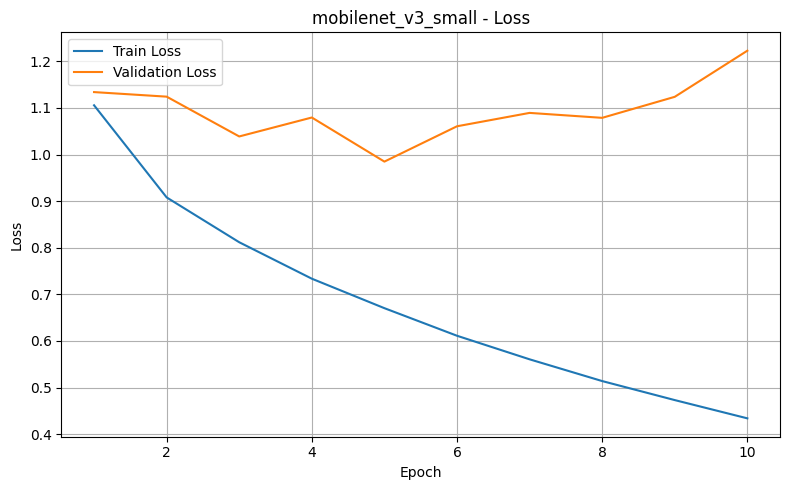

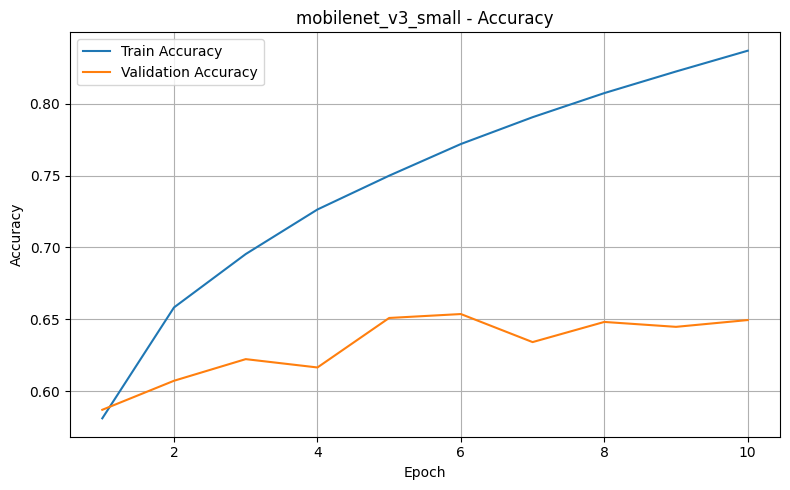

Best Loss model 경로: D:\emotion_recognition_project\05_models\mobilenet_v3_small_pretrained_GPU강제사용_수업수준안정화버전9_B128_best_loss.pt
Best Accuracy model 경로: D:\emotion_recognition_project\05_models\mobilenet_v3_small_pretrained_GPU강제사용_수업수준안정화버전9_B128_best_accuracy.pt
History CSV 경로: D:\emotion_recognition_project\06_outputs\mobilenet_v3_small_pretrained_GPU강제사용_수업수준안정화버전9_B128_history.csv


C:\Users\USER\AppData\Local\Temp\ipykernel_14140\2413969813.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path, map_locati


[mobilenet_v3_small] best_loss Validation 평가
Accuracy: 0.651


,class,precision,recall,f1_score
0,기쁨,0.907680,0.920389,0.913991
1,당황,0.677490,0.744567,0.709447
2,분노,0.651821,0.666935,0.659291
3,불안,0.475629,0.441339,0.457843
4,상처,0.472698,0.360366,0.408959
5,슬픔,0.640046,0.600080,0.619419
6,중립,0.663462,0.820208,0.733555


C:\Users\USER\AppData\Local\Temp\ipykernel_14140\3602689591.py:9: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_14140\3602689591.py:9: UserWarning: Glyph 49256 (\N{HANGUL SYLLABLE BBEUM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_14140\3602689591.py:9: UserWarning: Glyph 45817 (\N{HANGUL SYLLABLE DANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_14140\3602689591.py:9: UserWarning: Glyph 54889 (\N{HANGUL SYLLABLE HWANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_14140\3602689591.py:9: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_14140\3602689591.py:9: UserWarning: Glyph 45432 (\N{HANGUL SYLLABLE NO}) missing from font(s)

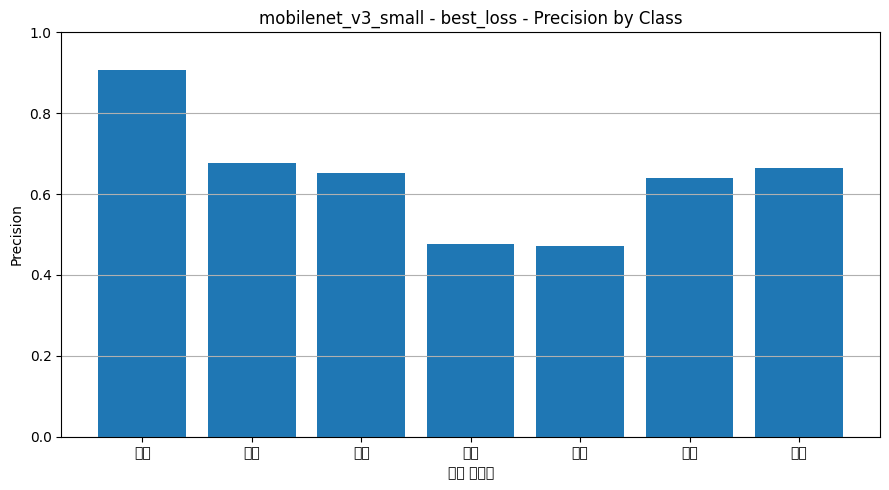

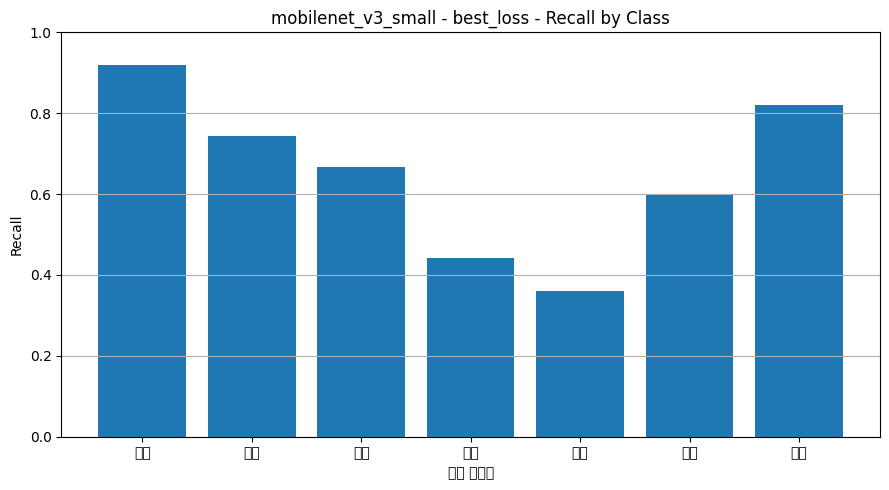

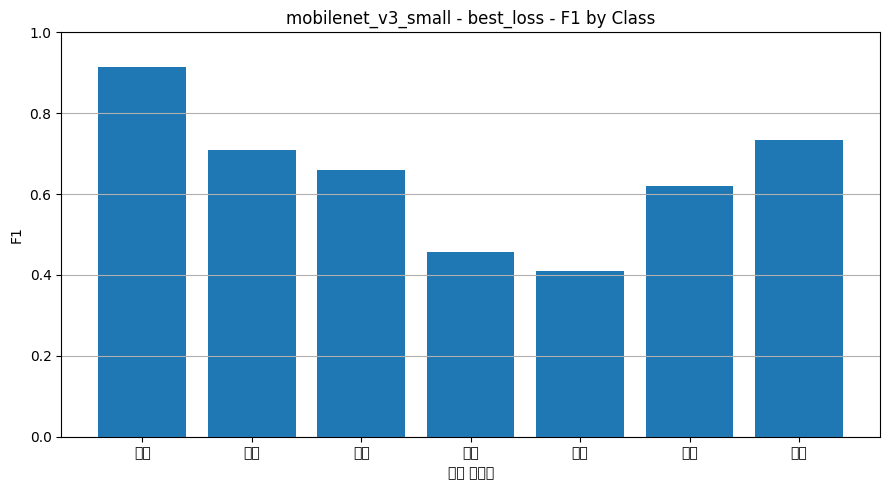

C:\Users\USER\AppData\Local\Temp\ipykernel_14140\3602689591.py:33: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_14140\3602689591.py:33: UserWarning: Glyph 49256 (\N{HANGUL SYLLABLE BBEUM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_14140\3602689591.py:33: UserWarning: Glyph 45817 (\N{HANGUL SYLLABLE DANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_14140\3602689591.py:33: UserWarning: Glyph 54889 (\N{HANGUL SYLLABLE HWANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_14140\3602689591.py:33: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_14140\3602689591.py:33: UserWarning: Glyph 45432 (\N{HANGUL SYLLABLE NO}) missing from f

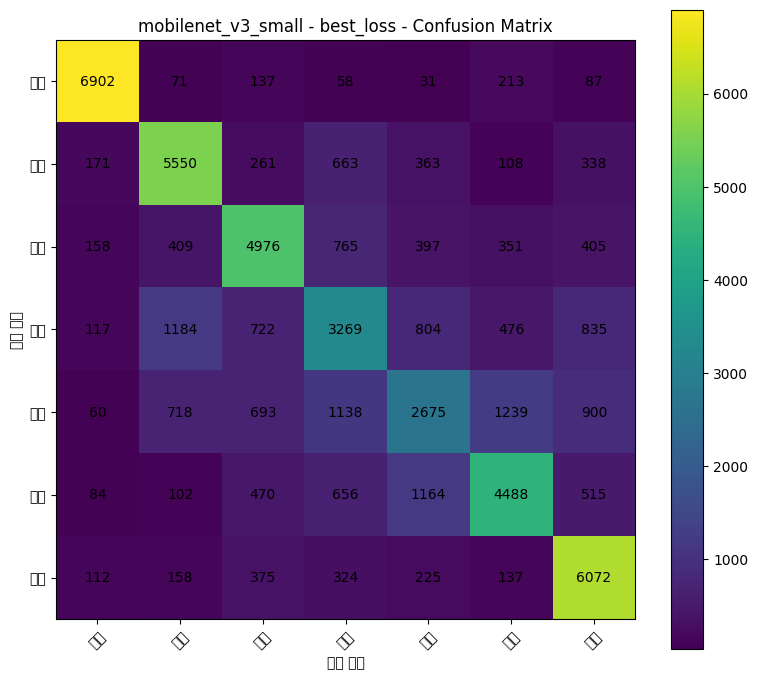

C:\Users\USER\AppData\Local\Temp\ipykernel_14140\2413969813.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path, map_locati


[mobilenet_v3_small] best_accuracy Validation 평가
Accuracy: 0.6537


,class,precision,recall,f1_score
0,기쁨,0.909270,0.922123,0.915651
1,당황,0.736947,0.693051,0.714325
2,분노,0.718750,0.638118,0.676038
3,불안,0.494103,0.429864,0.459750
4,상처,0.448063,0.411424,0.428963
5,슬픔,0.674273,0.604493,0.637479
6,중립,0.592657,0.874375,0.706467


C:\Users\USER\AppData\Local\Temp\ipykernel_14140\3602689591.py:9: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_14140\3602689591.py:9: UserWarning: Glyph 49256 (\N{HANGUL SYLLABLE BBEUM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_14140\3602689591.py:9: UserWarning: Glyph 45817 (\N{HANGUL SYLLABLE DANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_14140\3602689591.py:9: UserWarning: Glyph 54889 (\N{HANGUL SYLLABLE HWANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_14140\3602689591.py:9: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_14140\3602689591.py:9: UserWarning: Glyph 45432 (\N{HANGUL SYLLABLE NO}) missing from font(s)

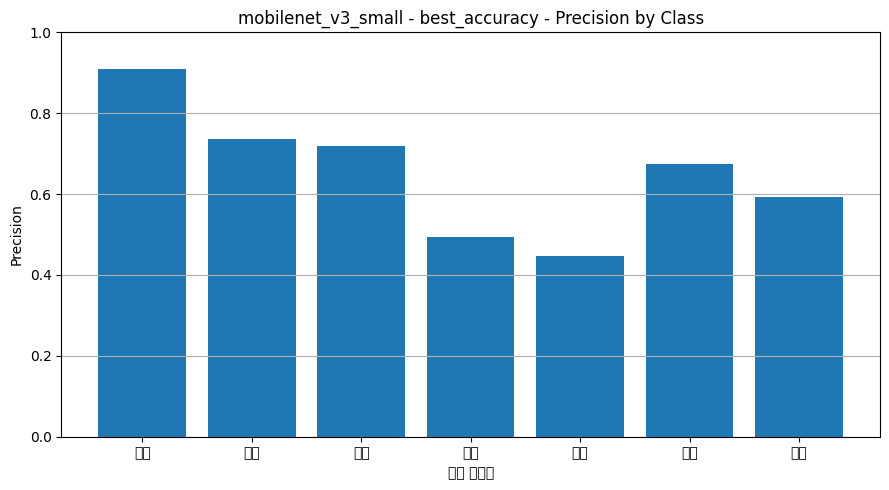

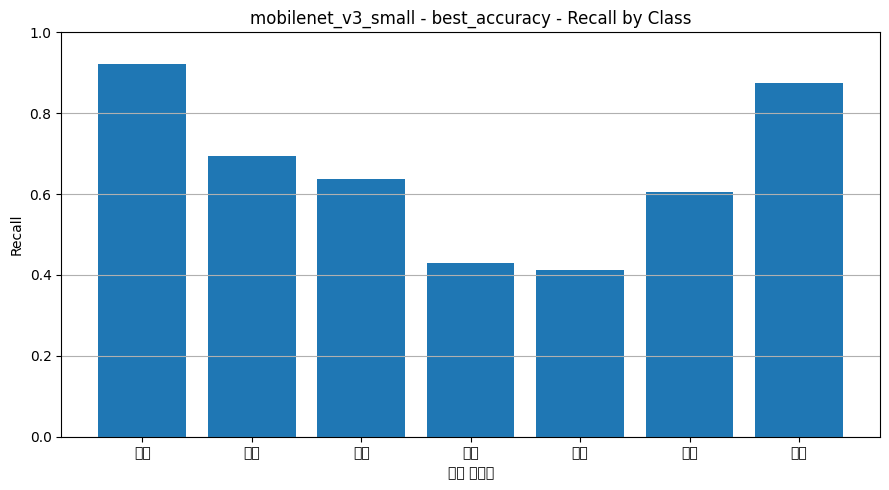

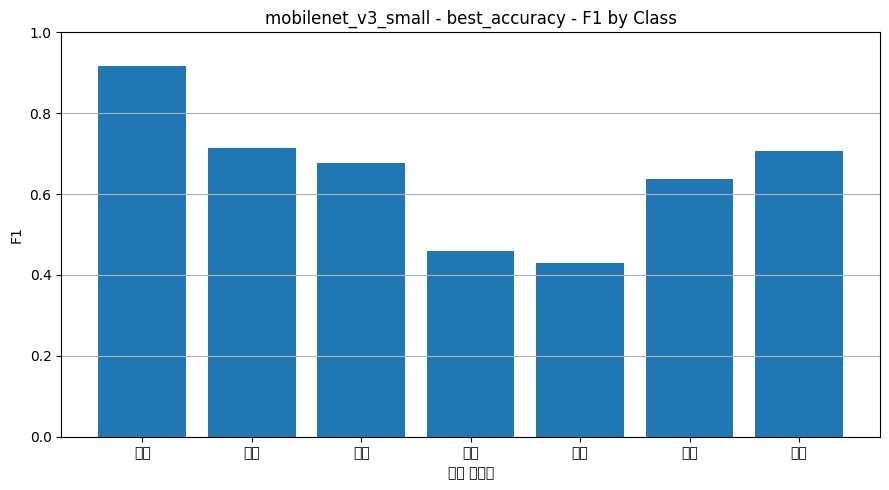

C:\Users\USER\AppData\Local\Temp\ipykernel_14140\3602689591.py:33: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_14140\3602689591.py:33: UserWarning: Glyph 49256 (\N{HANGUL SYLLABLE BBEUM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_14140\3602689591.py:33: UserWarning: Glyph 45817 (\N{HANGUL SYLLABLE DANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_14140\3602689591.py:33: UserWarning: Glyph 54889 (\N{HANGUL SYLLABLE HWANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_14140\3602689591.py:33: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_14140\3602689591.py:33: UserWarning: Glyph 45432 (\N{HANGUL SYLLABLE NO}) missing from f

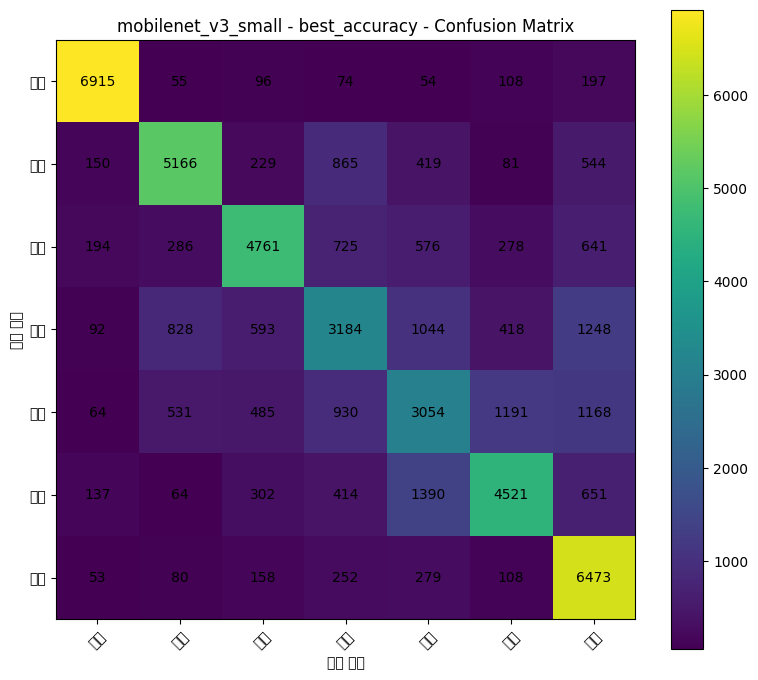

In [19]:
# 4-1. MobileNetV3 Small
mobilenet_history, mobilenet_best_loss_path, mobilenet_best_accuracy_path = train_model(
    model_name="mobilenet_v3_small",
    train_loader=train_loader,
    valid_loader=valid_loader,
    device=device,
    max_epochs=30,
    patience=5,
    learning_rate=0.001,
)

mobilenet_loss_result = evaluate_best_model(
    model_name="mobilenet_v3_small",
    valid_loader=valid_loader,
    device=device,
    best_model_path=mobilenet_best_loss_path,
    checkpoint_type="best_loss",
)

mobilenet_accuracy_result = evaluate_best_model(
    model_name="mobilenet_v3_small",
    valid_loader=valid_loader,
    device=device,
    best_model_path=mobilenet_best_accuracy_path,
    checkpoint_type="best_accuracy",
)

### 4-2. EfficientNetB0 본학습

같은 조건으로 EfficientNetB0을 학습한다.


===== efficientnet_b0 컬러 JPG GPU가속화버전3 학습 시작 =====
학습 시작 GPU 메모리: 0.03 GB allocated / 0.10 GB reserved
Batch 0/1747 | GPU 0.10 GB allocated / 0.25 GB reserved
Batch 50/1747 | GPU 0.15 GB allocated / 6.00 GB reserved
Batch 100/1747 | GPU 0.15 GB allocated / 6.00 GB reserved
Batch 150/1747 | GPU 0.15 GB allocated / 6.00 GB reserved
Batch 200/1747 | GPU 0.15 GB allocated / 6.00 GB reserved
Batch 250/1747 | GPU 0.15 GB allocated / 6.00 GB reserved
Batch 300/1747 | GPU 0.15 GB allocated / 6.00 GB reserved
Batch 350/1747 | GPU 0.15 GB allocated / 6.00 GB reserved
Batch 400/1747 | GPU 0.15 GB allocated / 6.00 GB reserved
Batch 450/1747 | GPU 0.15 GB allocated / 6.00 GB reserved
Batch 500/1747 | GPU 0.15 GB allocated / 6.00 GB reserved
Batch 550/1747 | GPU 0.15 GB allocated / 6.00 GB reserved
Batch 600/1747 | GPU 0.15 GB allocated / 6.00 GB reserved
Batch 650/1747 | GPU 0.15 GB allocated / 6.00 GB reserved
Batch 700/1747 | GPU 0.15 GB allocated / 6.00 GB reserved
Batch 750/1747 | GPU 0.15 GB 

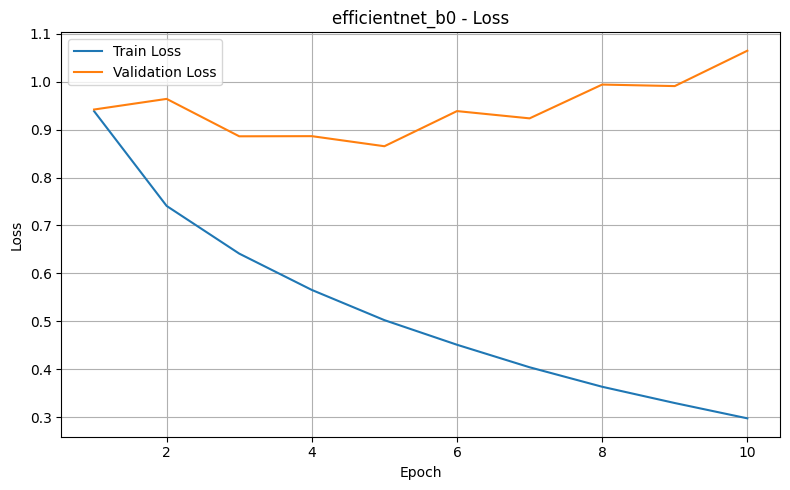

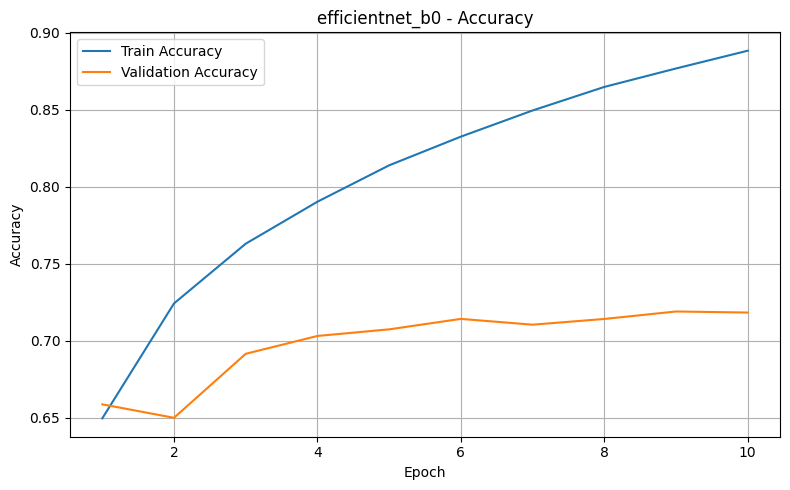

Best Loss model 경로: D:\emotion_recognition_project\05_models\efficientnet_b0_pretrained_GPU강제사용_수업수준안정화버전9_B128_best_loss.pt
Best Accuracy model 경로: D:\emotion_recognition_project\05_models\efficientnet_b0_pretrained_GPU강제사용_수업수준안정화버전9_B128_best_accuracy.pt
History CSV 경로: D:\emotion_recognition_project\06_outputs\efficientnet_b0_pretrained_GPU강제사용_수업수준안정화버전9_B128_history.csv


C:\Users\USER\AppData\Local\Temp\ipykernel_14140\2413969813.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path, map_locati


[efficientnet_b0] best_loss Validation 평가
Accuracy: 0.7074


,class,precision,recall,f1_score
0,기쁨,0.948631,0.933324,0.940916
1,당황,0.772551,0.720419,0.745574
2,분노,0.720789,0.749095,0.734670
3,불안,0.538861,0.560686,0.549557
4,상처,0.483385,0.462481,0.472702
5,슬픔,0.702155,0.657842,0.679277
6,중립,0.778899,0.865595,0.819962


C:\Users\USER\AppData\Local\Temp\ipykernel_14140\3602689591.py:9: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_14140\3602689591.py:9: UserWarning: Glyph 49256 (\N{HANGUL SYLLABLE BBEUM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_14140\3602689591.py:9: UserWarning: Glyph 45817 (\N{HANGUL SYLLABLE DANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_14140\3602689591.py:9: UserWarning: Glyph 54889 (\N{HANGUL SYLLABLE HWANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_14140\3602689591.py:9: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_14140\3602689591.py:9: UserWarning: Glyph 45432 (\N{HANGUL SYLLABLE NO}) missing from font(s)

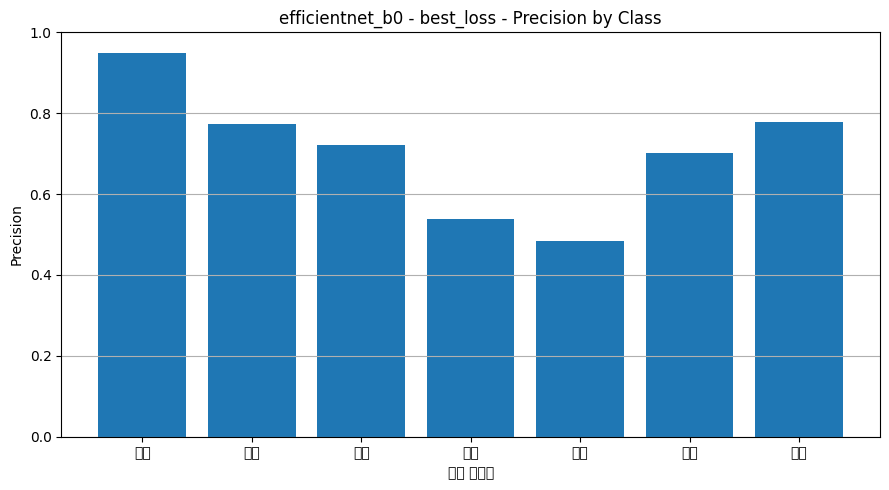

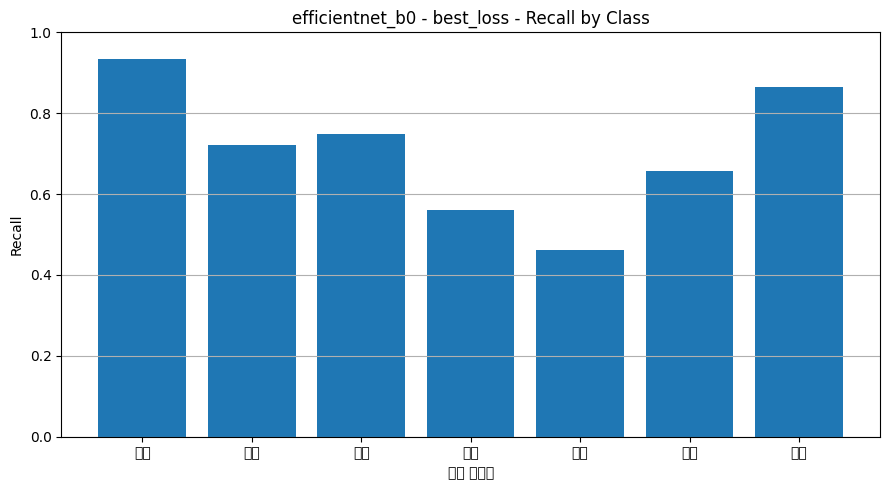

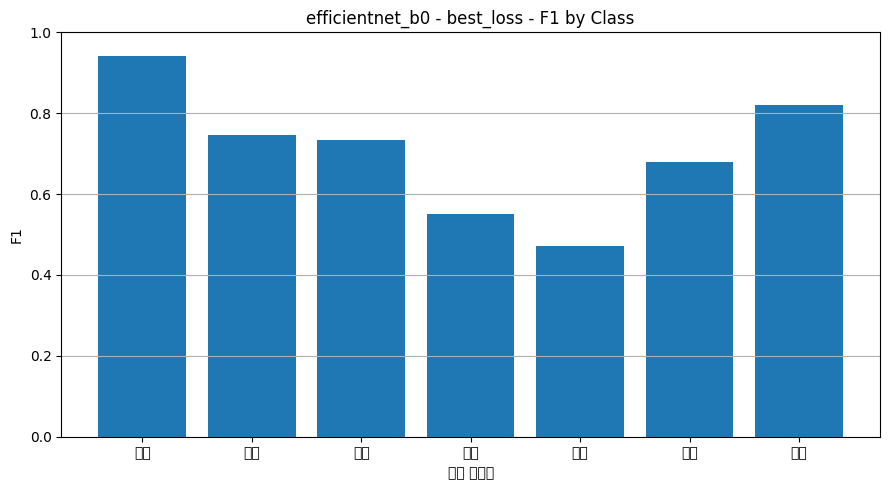

C:\Users\USER\AppData\Local\Temp\ipykernel_14140\3602689591.py:33: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_14140\3602689591.py:33: UserWarning: Glyph 49256 (\N{HANGUL SYLLABLE BBEUM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_14140\3602689591.py:33: UserWarning: Glyph 45817 (\N{HANGUL SYLLABLE DANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_14140\3602689591.py:33: UserWarning: Glyph 54889 (\N{HANGUL SYLLABLE HWANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_14140\3602689591.py:33: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_14140\3602689591.py:33: UserWarning: Glyph 45432 (\N{HANGUL SYLLABLE NO}) missing from f

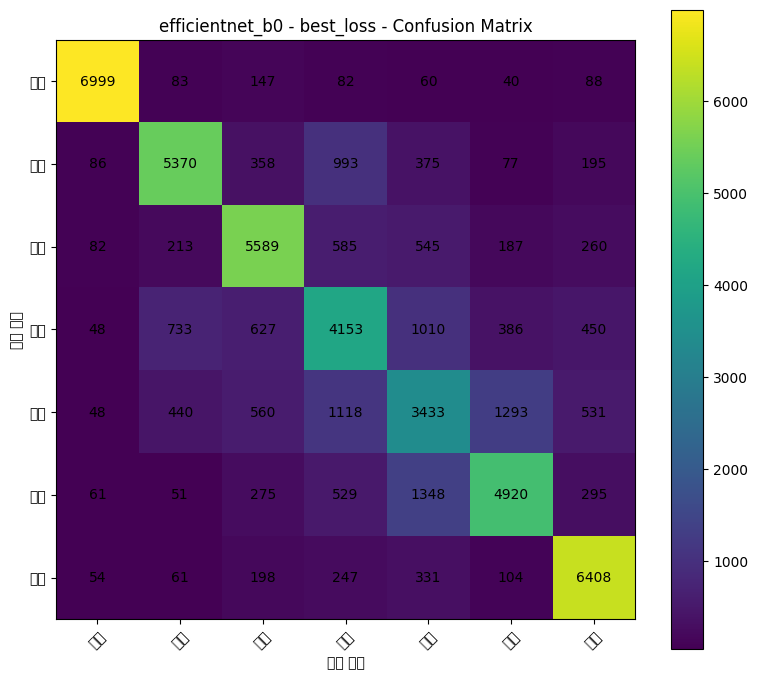

C:\Users\USER\AppData\Local\Temp\ipykernel_14140\2413969813.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path, map_locati


[efficientnet_b0] best_accuracy Validation 평가
Accuracy: 0.719


,class,precision,recall,f1_score
0,기쁨,0.930588,0.958261,0.944222
1,당황,0.744591,0.757177,0.750831
2,분노,0.709073,0.776169,0.741106
3,불안,0.552701,0.540165,0.546361
4,상처,0.532104,0.466658,0.497237
5,슬픔,0.721505,0.679636,0.699945
6,중립,0.802238,0.852087,0.826412


C:\Users\USER\AppData\Local\Temp\ipykernel_14140\3602689591.py:9: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_14140\3602689591.py:9: UserWarning: Glyph 49256 (\N{HANGUL SYLLABLE BBEUM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_14140\3602689591.py:9: UserWarning: Glyph 45817 (\N{HANGUL SYLLABLE DANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_14140\3602689591.py:9: UserWarning: Glyph 54889 (\N{HANGUL SYLLABLE HWANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_14140\3602689591.py:9: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_14140\3602689591.py:9: UserWarning: Glyph 45432 (\N{HANGUL SYLLABLE NO}) missing from font(s)

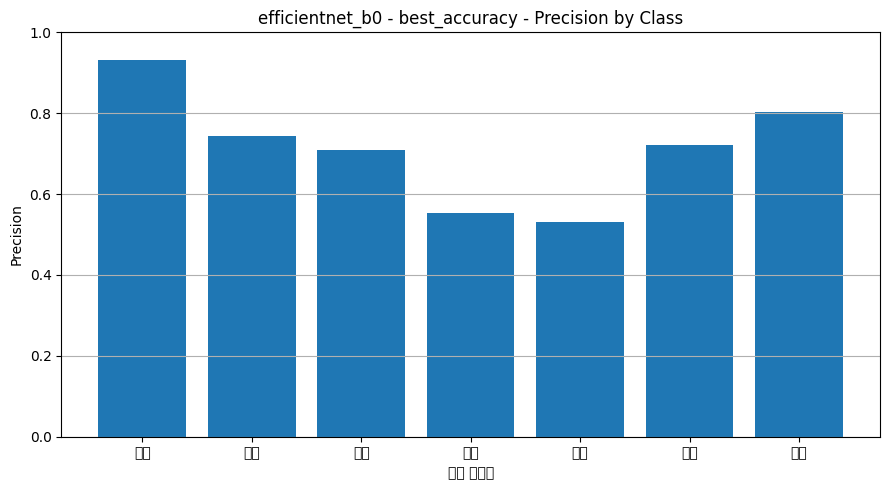

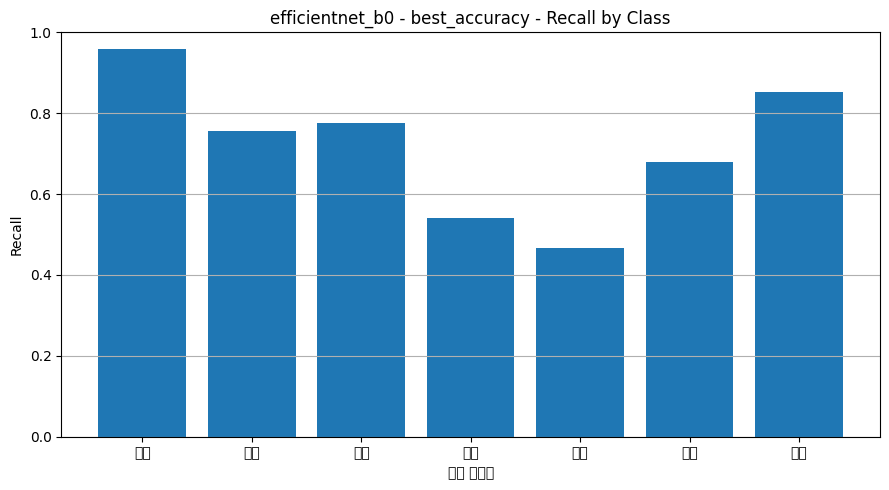

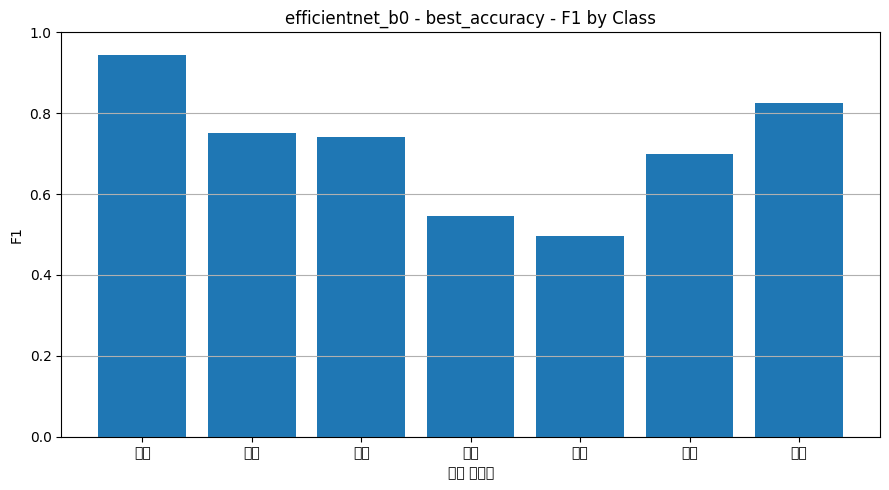

C:\Users\USER\AppData\Local\Temp\ipykernel_14140\3602689591.py:33: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_14140\3602689591.py:33: UserWarning: Glyph 49256 (\N{HANGUL SYLLABLE BBEUM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_14140\3602689591.py:33: UserWarning: Glyph 45817 (\N{HANGUL SYLLABLE DANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_14140\3602689591.py:33: UserWarning: Glyph 54889 (\N{HANGUL SYLLABLE HWANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_14140\3602689591.py:33: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_14140\3602689591.py:33: UserWarning: Glyph 45432 (\N{HANGUL SYLLABLE NO}) missing from f

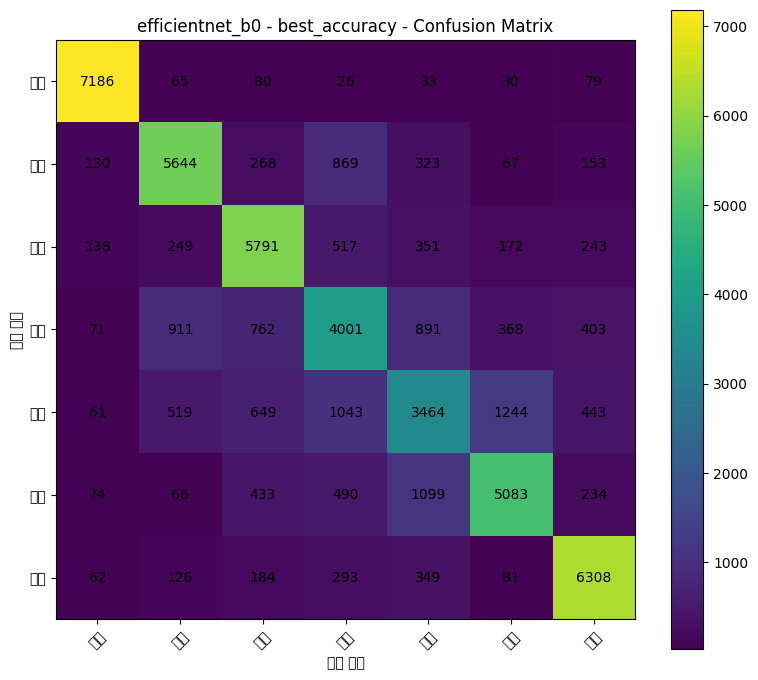

In [20]:
# 4-2. EfficientNetB0
efficientnet_history, efficientnet_best_loss_path, efficientnet_best_accuracy_path = train_model(
    model_name="efficientnet_b0",
    train_loader=train_loader,
    valid_loader=valid_loader,
    device=device,
    max_epochs=30,
    patience=5,
    learning_rate=0.001,
)

efficientnet_loss_result = evaluate_best_model(
    model_name="efficientnet_b0",
    valid_loader=valid_loader,
    device=device,
    best_model_path=efficientnet_best_loss_path,
    checkpoint_type="best_loss",
)

efficientnet_accuracy_result = evaluate_best_model(
    model_name="efficientnet_b0",
    valid_loader=valid_loader,
    device=device,
    best_model_path=efficientnet_best_accuracy_path,
    checkpoint_type="best_accuracy",
)

### 4-3. ResNet18 본학습

마지막으로 같은 조건에서 ResNet18을 학습한다.


===== resnet18 컬러 JPG GPU가속화버전3 학습 시작 =====
학습 시작 GPU 메모리: 0.06 GB allocated / 0.12 GB reserved
Batch 0/1747 | GPU 0.13 GB allocated / 0.26 GB reserved
Batch 50/1747 | GPU 0.26 GB allocated / 2.06 GB reserved
Batch 100/1747 | GPU 0.26 GB allocated / 2.06 GB reserved
Batch 150/1747 | GPU 0.26 GB allocated / 2.06 GB reserved
Batch 200/1747 | GPU 0.26 GB allocated / 2.06 GB reserved
Batch 250/1747 | GPU 0.26 GB allocated / 2.06 GB reserved
Batch 300/1747 | GPU 0.26 GB allocated / 2.06 GB reserved
Batch 350/1747 | GPU 0.26 GB allocated / 2.06 GB reserved
Batch 400/1747 | GPU 0.26 GB allocated / 2.06 GB reserved
Batch 450/1747 | GPU 0.26 GB allocated / 2.06 GB reserved
Batch 500/1747 | GPU 0.26 GB allocated / 2.06 GB reserved
Batch 550/1747 | GPU 0.26 GB allocated / 2.06 GB reserved
Batch 600/1747 | GPU 0.26 GB allocated / 2.06 GB reserved
Batch 650/1747 | GPU 0.26 GB allocated / 2.06 GB reserved
Batch 700/1747 | GPU 0.26 GB allocated / 2.06 GB reserved
Batch 750/1747 | GPU 0.26 GB allocat

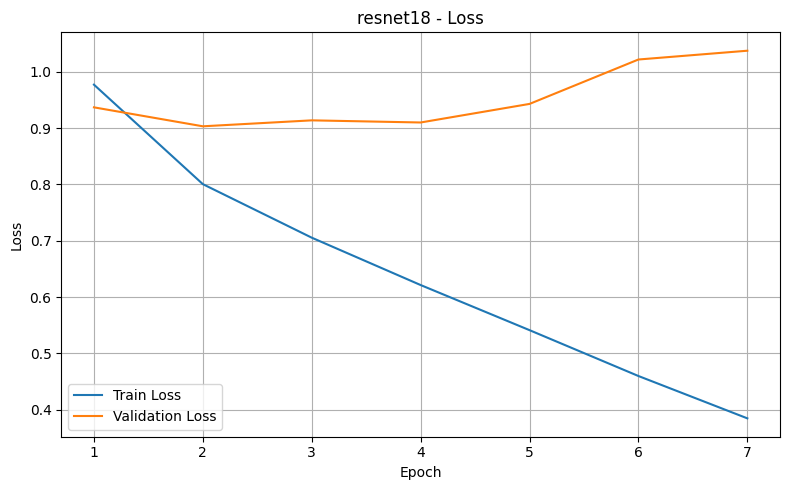

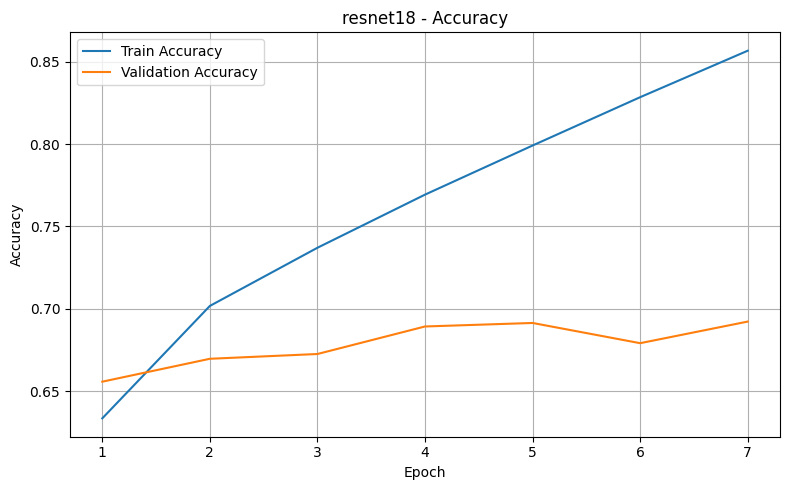

Best Loss model 경로: D:\emotion_recognition_project\05_models\resnet18_pretrained_GPU강제사용_수업수준안정화버전9_B128_best_loss.pt
Best Accuracy model 경로: D:\emotion_recognition_project\05_models\resnet18_pretrained_GPU강제사용_수업수준안정화버전9_B128_best_accuracy.pt
History CSV 경로: D:\emotion_recognition_project\06_outputs\resnet18_pretrained_GPU강제사용_수업수준안정화버전9_B128_history.csv


C:\Users\USER\AppData\Local\Temp\ipykernel_14140\2413969813.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path, map_locati


[resnet18] best_loss Validation 평가
Accuracy: 0.6698


,class,precision,recall,f1_score
0,기쁨,0.884441,0.963462,0.922262
1,당황,0.652239,0.705527,0.677837
2,분노,0.706519,0.717598,0.712015
3,불안,0.525093,0.436479,0.476703
4,상처,0.436759,0.302843,0.357677
5,슬픔,0.608278,0.736863,0.666425
6,중립,0.764965,0.821694,0.792315


C:\Users\USER\AppData\Local\Temp\ipykernel_14140\3602689591.py:9: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_14140\3602689591.py:9: UserWarning: Glyph 49256 (\N{HANGUL SYLLABLE BBEUM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_14140\3602689591.py:9: UserWarning: Glyph 45817 (\N{HANGUL SYLLABLE DANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_14140\3602689591.py:9: UserWarning: Glyph 54889 (\N{HANGUL SYLLABLE HWANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_14140\3602689591.py:9: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_14140\3602689591.py:9: UserWarning: Glyph 45432 (\N{HANGUL SYLLABLE NO}) missing from font(s)

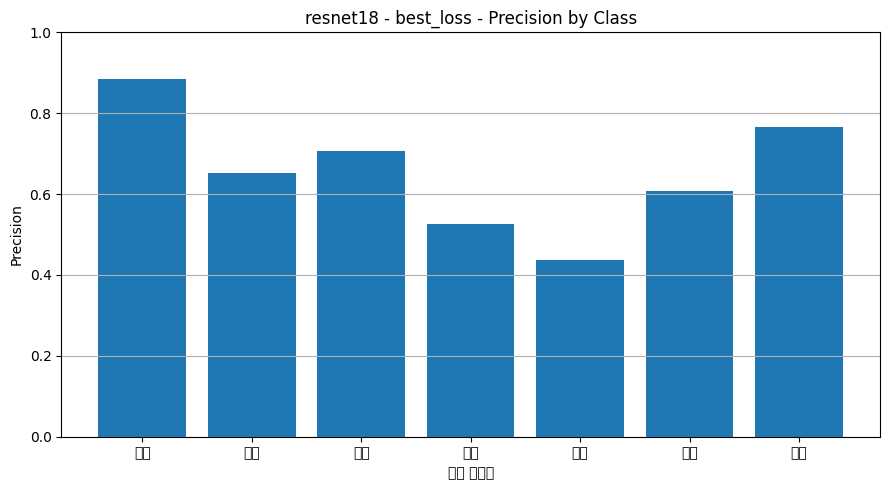

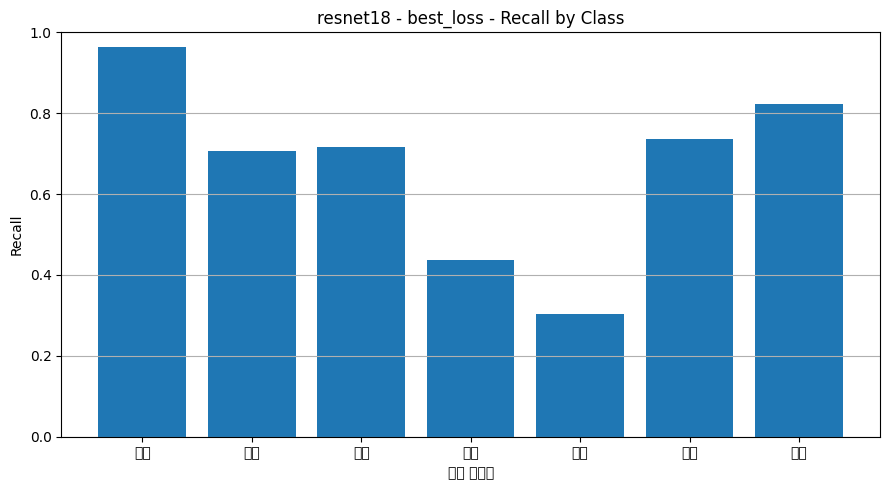

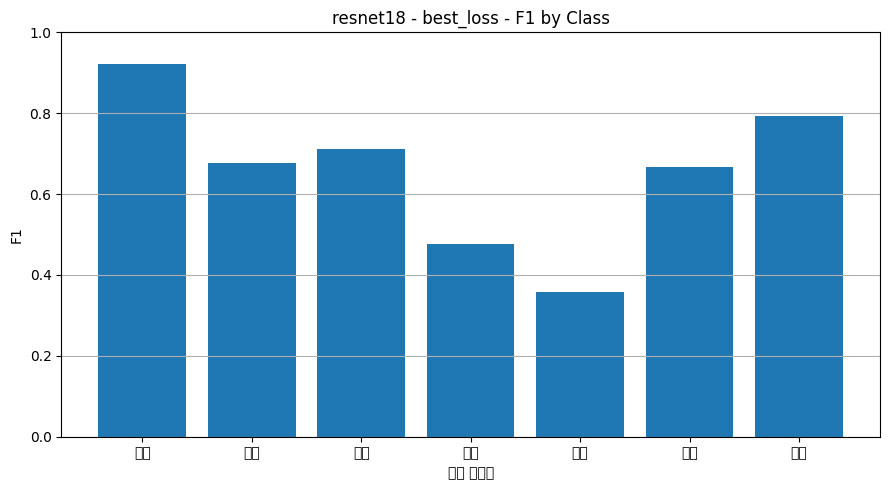

C:\Users\USER\AppData\Local\Temp\ipykernel_14140\3602689591.py:33: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_14140\3602689591.py:33: UserWarning: Glyph 49256 (\N{HANGUL SYLLABLE BBEUM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_14140\3602689591.py:33: UserWarning: Glyph 45817 (\N{HANGUL SYLLABLE DANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_14140\3602689591.py:33: UserWarning: Glyph 54889 (\N{HANGUL SYLLABLE HWANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_14140\3602689591.py:33: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_14140\3602689591.py:33: UserWarning: Glyph 45432 (\N{HANGUL SYLLABLE NO}) missing from f

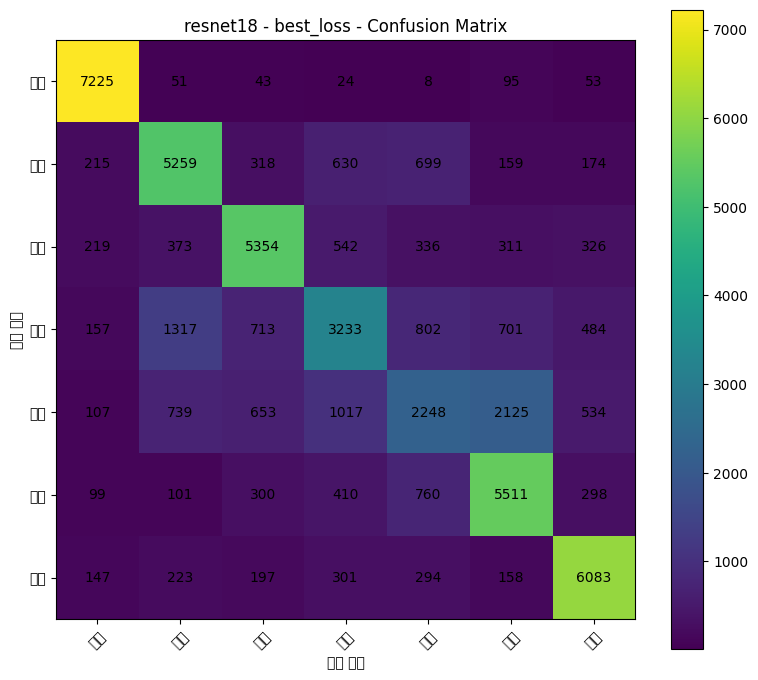

C:\Users\USER\AppData\Local\Temp\ipykernel_14140\2413969813.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path, map_locati


[resnet18] best_accuracy Validation 평가
Accuracy: 0.6923


,class,precision,recall,f1_score
0,기쁨,0.937275,0.936525,0.936900
1,당황,0.715882,0.722028,0.718942
2,분노,0.775993,0.673234,0.720970
3,불안,0.503789,0.529499,0.516324
4,상처,0.473851,0.402802,0.435447
5,슬픔,0.675977,0.689263,0.682555
6,중립,0.739155,0.890720,0.807890


C:\Users\USER\AppData\Local\Temp\ipykernel_14140\3602689591.py:9: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_14140\3602689591.py:9: UserWarning: Glyph 49256 (\N{HANGUL SYLLABLE BBEUM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_14140\3602689591.py:9: UserWarning: Glyph 45817 (\N{HANGUL SYLLABLE DANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_14140\3602689591.py:9: UserWarning: Glyph 54889 (\N{HANGUL SYLLABLE HWANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_14140\3602689591.py:9: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_14140\3602689591.py:9: UserWarning: Glyph 45432 (\N{HANGUL SYLLABLE NO}) missing from font(s)

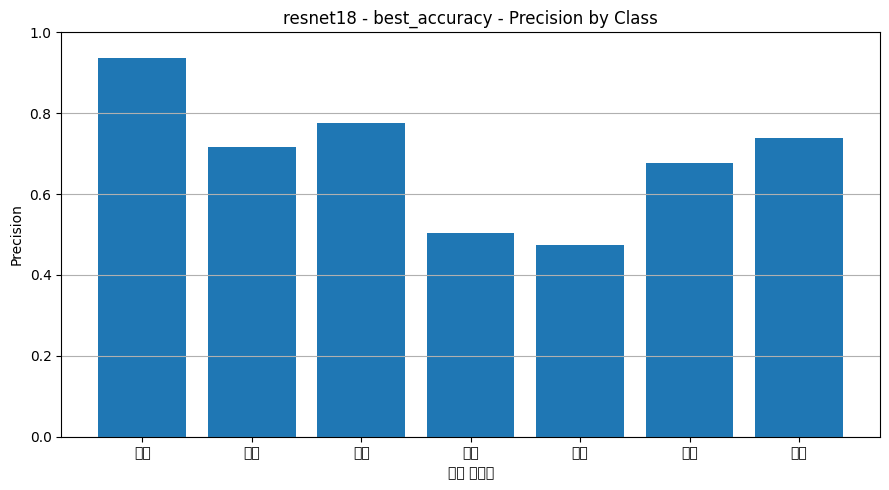

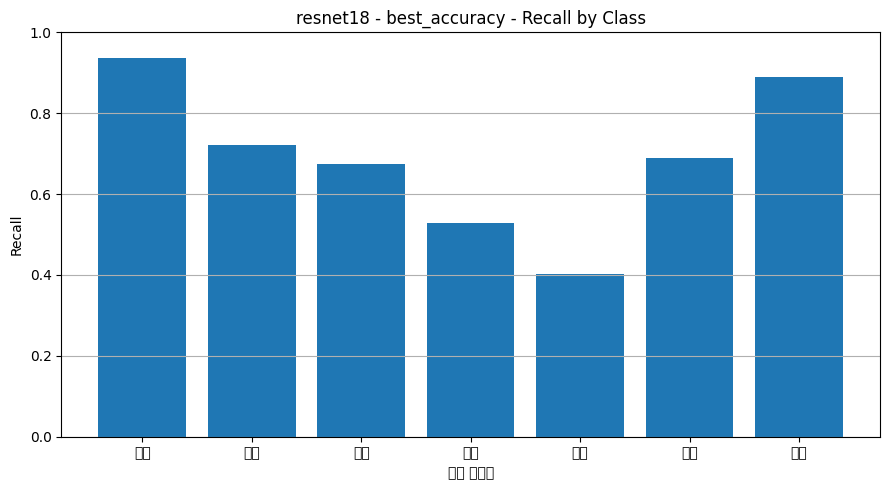

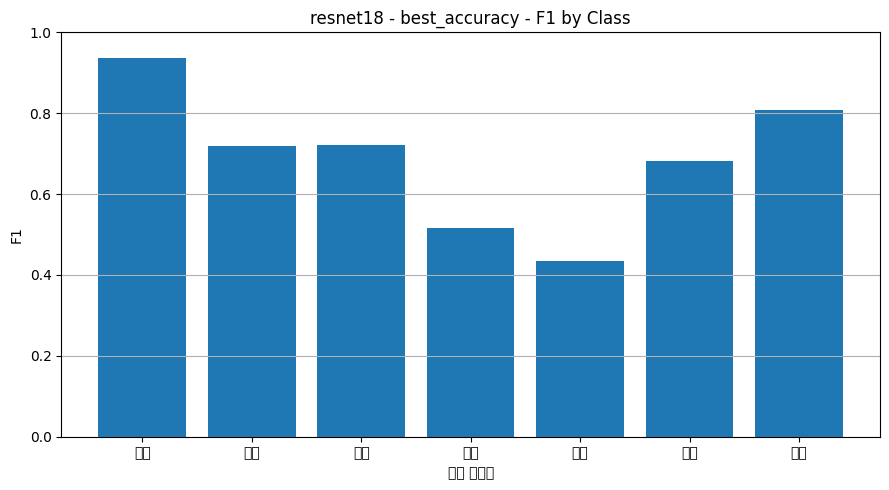

C:\Users\USER\AppData\Local\Temp\ipykernel_14140\3602689591.py:33: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_14140\3602689591.py:33: UserWarning: Glyph 49256 (\N{HANGUL SYLLABLE BBEUM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_14140\3602689591.py:33: UserWarning: Glyph 45817 (\N{HANGUL SYLLABLE DANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_14140\3602689591.py:33: UserWarning: Glyph 54889 (\N{HANGUL SYLLABLE HWANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_14140\3602689591.py:33: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_14140\3602689591.py:33: UserWarning: Glyph 45432 (\N{HANGUL SYLLABLE NO}) missing from f

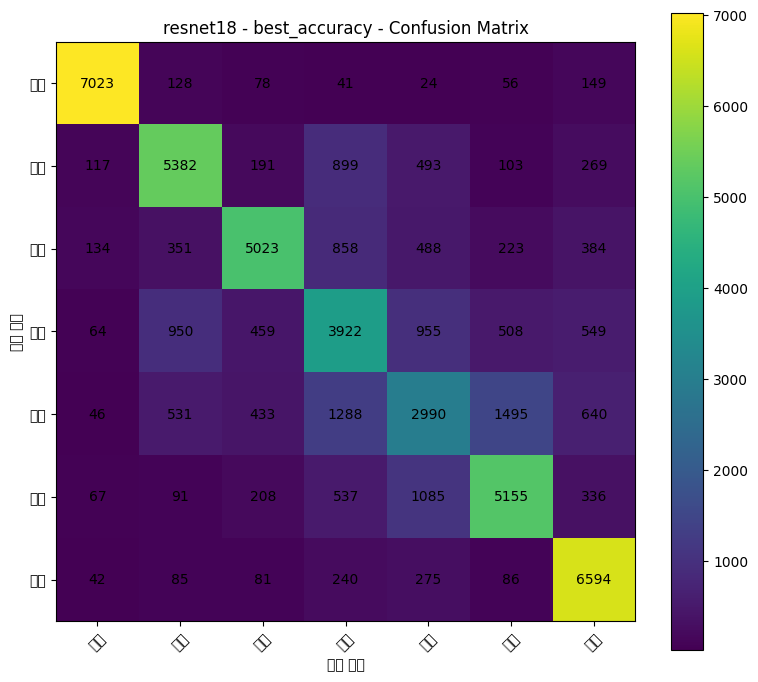

In [21]:
# 4-3. ResNet18
resnet_history, resnet_best_loss_path, resnet_best_accuracy_path = train_model(
    model_name="resnet18",
    train_loader=train_loader,
    valid_loader=valid_loader,
    device=device,
    max_epochs=30,
    patience=5,
    learning_rate=0.001,
)

resnet_loss_result = evaluate_best_model(
    model_name="resnet18",
    valid_loader=valid_loader,
    device=device,
    best_model_path=resnet_best_loss_path,
    checkpoint_type="best_loss",
)

resnet_accuracy_result = evaluate_best_model(
    model_name="resnet18",
    valid_loader=valid_loader,
    device=device,
    best_model_path=resnet_best_accuracy_path,
    checkpoint_type="best_accuracy",
)

## 5. 세 모델 최종 비교

컬러 JPG/JPEG 실험에서는 세 모델 각각의 두 체크포인트를 비교한다.

- Best Validation Loss
- Best Validation Accuracy

총 6개 체크포인트의 Accuracy / 평균 Precision / 평균 Recall / 평균 F1-score를 비교하고,
각 모델의 학습 중 Best Validation Loss와 Best Validation Accuracy도 별도 표로 저장한다.

,model,checkpoint_type,accuracy,mean_precision,mean_recall,mean_f1
0,mobilenet_v3_small,best_loss,0.650961,0.641261,0.650555,0.643215
1,mobilenet_v3_small,best_accuracy,0.653685,0.653438,0.653350,0.648382
2,efficientnet_b0,best_loss,0.707363,0.706467,0.707063,0.706094
3,efficientnet_b0,best_accuracy,0.718969,0.713257,0.718593,0.715159
4,resnet18,best_loss,0.669781,0.654042,0.669209,0.657891
5,resnet18,best_accuracy,0.692342,0.688846,0.692010,0.688433


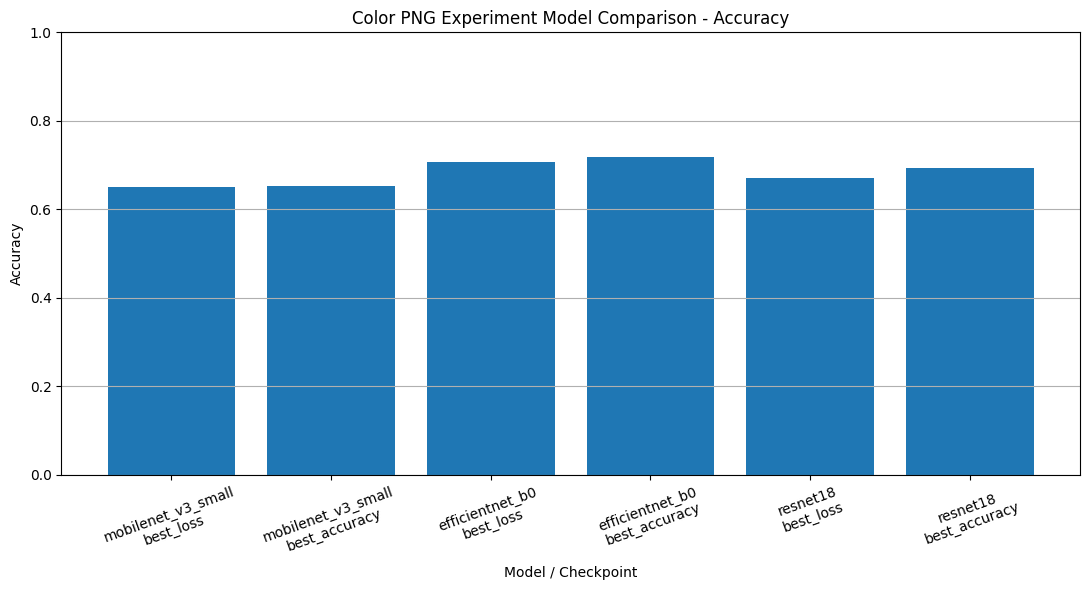

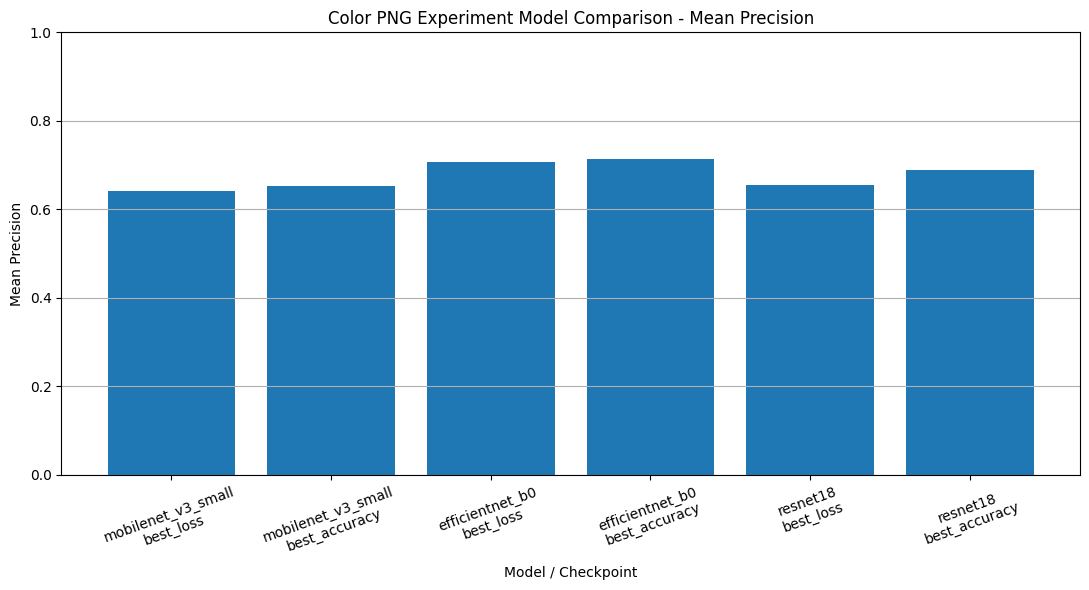

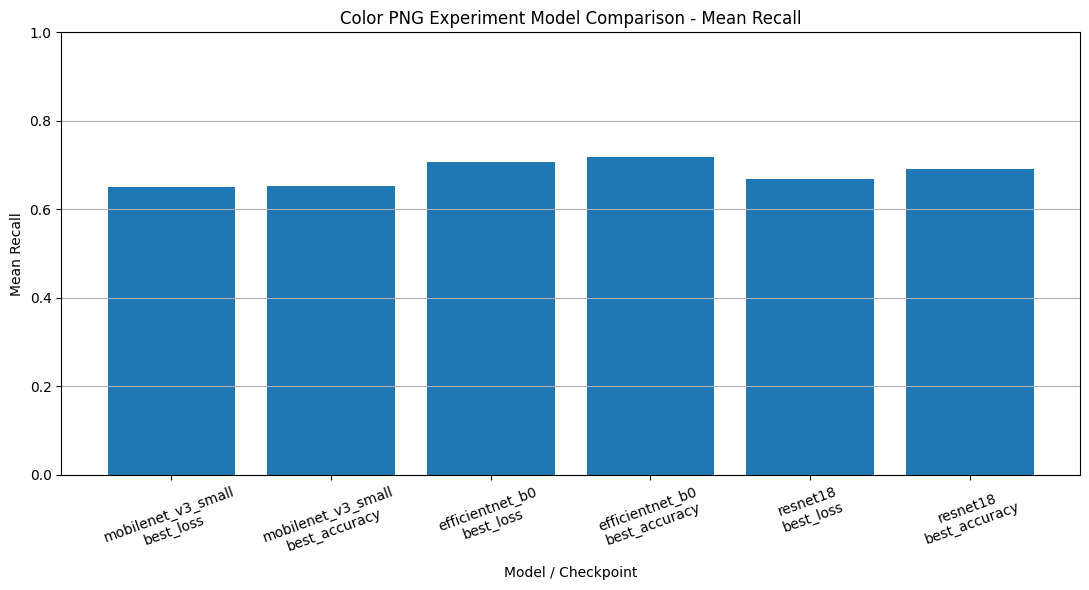

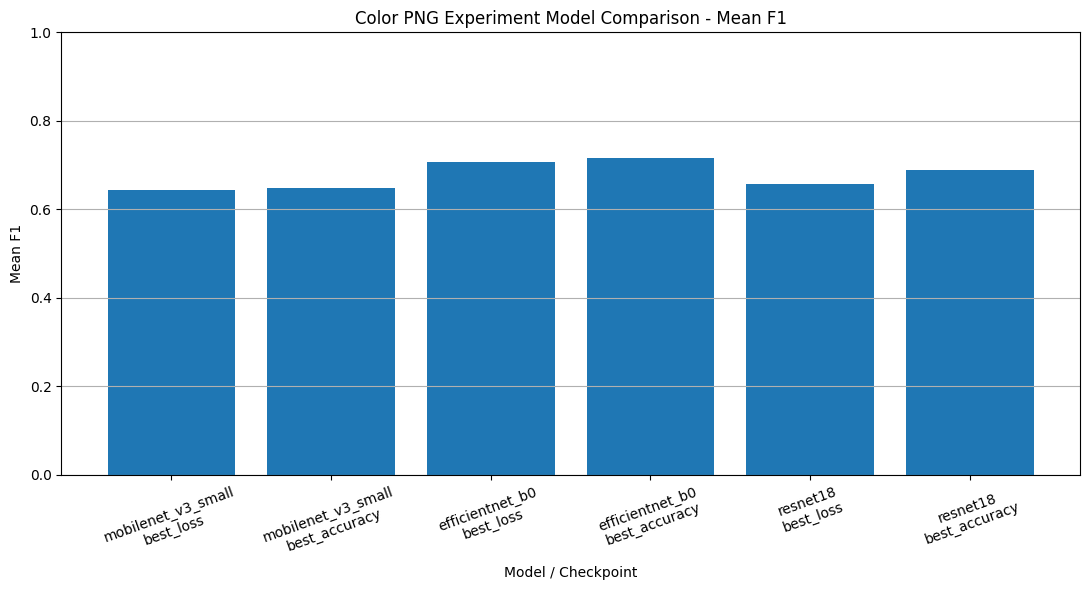

,model,best_valid_loss,best_valid_accuracy
0,mobilenet_v3_small,0.984821,0.653685
1,efficientnet_b0,0.865263,0.718969
2,resnet18,0.903427,0.692342


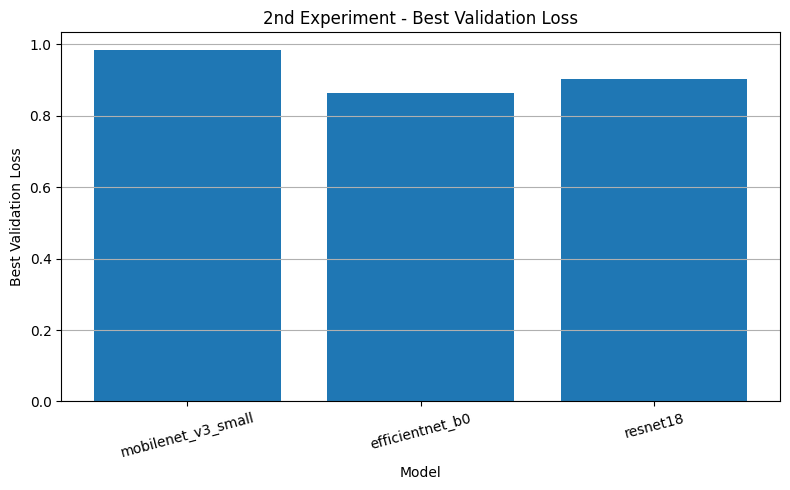

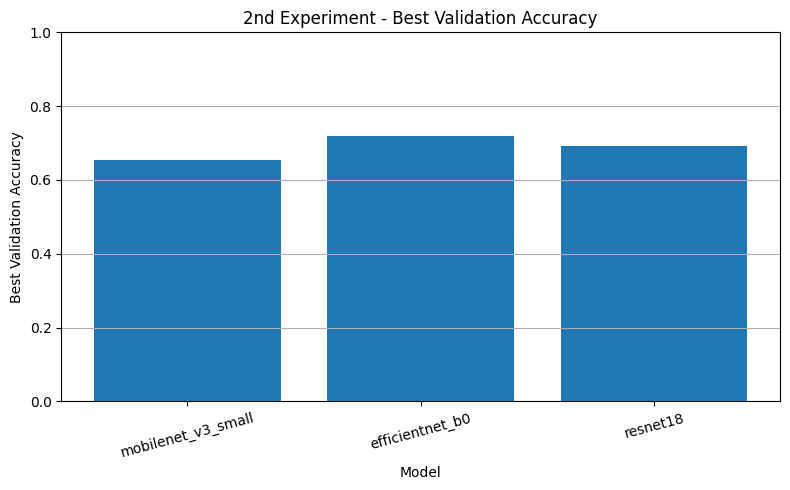


세 모델 2차 학습 및 평가 종료
모델 저장 폴더: D:\emotion_recognition_project\05_models
결과 저장 폴더: D:\emotion_recognition_project\06_outputs
6개 체크포인트 비교 CSV: D:\emotion_recognition_project\06_outputs\pretrained_GPU강제사용_수업수준안정화버전9_B128_model_comparison_metrics.csv
Best Loss / Accuracy 요약 CSV: D:\emotion_recognition_project\06_outputs\pretrained_GPU강제사용_수업수준안정화버전9_B128_best_loss_accuracy_summary.csv


In [22]:
# --------------------------------------------------
# 세 모델 × 두 체크포인트 최종 비교
# --------------------------------------------------
model_results = [
    mobilenet_loss_result,
    mobilenet_accuracy_result,
    efficientnet_loss_result,
    efficientnet_accuracy_result,
    resnet_loss_result,
    resnet_accuracy_result,
]

results_df = pd.DataFrame(model_results)

results_path = (
    OUTPUT_DIR
    / f"pretrained_{EXPERIMENT_TAG}_model_comparison_metrics.csv"
)

results_df.to_csv(
    results_path,
    index=False,
    encoding="utf-8-sig",
)

display(results_df)

results_df["display_name"] = (
    results_df["model"]
    + "\n"
    + results_df["checkpoint_type"]
)

comparison_metrics = [
    ("accuracy", "Accuracy"),
    ("mean_precision", "Mean Precision"),
    ("mean_recall", "Mean Recall"),
    ("mean_f1", "Mean F1"),
]

for column, title in comparison_metrics:
    plt.figure(figsize=(11, 6))
    plt.bar(results_df["display_name"], results_df[column])
    plt.ylim(0, 1)
    plt.xlabel("Model / Checkpoint")
    plt.ylabel(title)
    plt.title(f"Color PNG Experiment Model Comparison - {title}")
    plt.xticks(rotation=20)
    plt.grid(axis="y")
    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR
        / f"pretrained_{EXPERIMENT_TAG}_model_comparison_{column}.png",
        dpi=150,
    )
    plt.show()
    plt.close()


# 각 모델의 학습 과정에서 기록된 최저 Loss / 최고 Accuracy 요약
best_summary_df = pd.DataFrame([
    {
        "model": "mobilenet_v3_small",
        "best_valid_loss": mobilenet_history["valid_loss"].min(),
        "best_valid_accuracy": mobilenet_history["valid_accuracy"].max(),
    },
    {
        "model": "efficientnet_b0",
        "best_valid_loss": efficientnet_history["valid_loss"].min(),
        "best_valid_accuracy": efficientnet_history["valid_accuracy"].max(),
    },
    {
        "model": "resnet18",
        "best_valid_loss": resnet_history["valid_loss"].min(),
        "best_valid_accuracy": resnet_history["valid_accuracy"].max(),
    },
])

best_summary_path = (
    OUTPUT_DIR
    / f"pretrained_{EXPERIMENT_TAG}_best_loss_accuracy_summary.csv"
)

best_summary_df.to_csv(
    best_summary_path,
    index=False,
    encoding="utf-8-sig",
)

display(best_summary_df)


plt.figure(figsize=(8, 5))
plt.bar(best_summary_df["model"], best_summary_df["best_valid_loss"])
plt.xlabel("Model")
plt.ylabel("Best Validation Loss")
plt.title("2nd Experiment - Best Validation Loss")
plt.xticks(rotation=15)
plt.grid(axis="y")
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR
    / f"pretrained_{EXPERIMENT_TAG}_comparison_best_valid_loss.png",
    dpi=150,
)
plt.show()
plt.close()


plt.figure(figsize=(8, 5))
plt.bar(best_summary_df["model"], best_summary_df["best_valid_accuracy"])
plt.ylim(0, 1)
plt.xlabel("Model")
plt.ylabel("Best Validation Accuracy")
plt.title("2nd Experiment - Best Validation Accuracy")
plt.xticks(rotation=15)
plt.grid(axis="y")
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR
    / f"pretrained_{EXPERIMENT_TAG}_comparison_best_valid_accuracy.png",
    dpi=150,
)
plt.show()
plt.close()

print("\n세 모델 2차 학습 및 평가 종료")
print("모델 저장 폴더:", MODEL_DIR)
print("결과 저장 폴더:", OUTPUT_DIR)
print("6개 체크포인트 비교 CSV:", results_path)
print("Best Loss / Accuracy 요약 CSV:", best_summary_path)

### 발표 때 설명할 핵심 - SSD 복사 GPU 가속화 버전5

1. 기존 224×224 컬러 JPG/JPEG는 D: HDD에 보존했다.
2. D:의 `processed/train`, `processed/valid`를 C: SSD에 **복사**했다.
3. 파일을 이동하거나 삭제하지 않았으며 원본 데이터는 그대로 유지했다.
4. 실제 학습에서는 C: SSD 복사본을 읽어 HDD 랜덤 I/O 병목을 줄였다.
5. Batch Size 128, AMP, channels_last, cuDNN benchmark, TF32,
   pin_memory, non_blocking 설정을 유지했다.
6. 결과 태그는 `v2_dual_best_color_JPG_SSD복사_GPU가속화버전5_bs256`이다.